# Notebook 05 — Final consolidation and statistical checks

**Purpose.** This notebook consolidates the remaining figure panels, source-data
tables, locked numbers, and statistical checks needed after Notebooks 01–04. It
does not rerun model inference, model training, Bayesian optimisation, or the
full benchmark matching pipeline. Instead, it reads frozen artefacts from
`release/frozen_results/`, `release/manifests/`, and the source-data files
produced by the earlier notebooks.

**Audience.** This notebook is intended for collaborators and reviewers who
want to verify the final numbers used in the manuscript figures, including
statistical comparisons, gold-standard count disclosure, supplemental heatmaps,
global performance summaries, count-agreement plots, locked pixel-Dice values,
and final output manifests.

## Scope

Notebook 05 performs post-hoc consolidation only. The benchmark outputs are
treated as frozen inputs. The notebook:

1. checks selected statistical comparisons from frozen per-image metrics;
2. generates missing supplemental or manuscript-ready plots from saved source
   tables;
3. writes source CSVs for every generated plot;
4. records final locked numbers for manuscript reporting;
5. creates an output manifest for submission auditing.

No full-benchmark metric is recomputed from raw images in this notebook.
Image and mask files may be loaded only for qualitative visualisation or
single-image sanity checks; all benchmark-level performance numbers come from
the frozen benchmark outputs.

## What this notebook produces

All files are written to `release/figures/notebook05/`.

| Section | Output | Purpose | Main source |
|---|---|---|---|
| §1 | `source_fig3_wilcoxon.csv`; `fig3_classical_wilcoxon_delta.{svg,png}` | Paired statistical check for the classical before/after comparison | `outputs/classical_bfr_aft/or_matching/per_image_metrics.csv` |
| §2 | `figS_gt_count_disclosure.{svg,png}` + source CSV | Gold-standard count disclosure comparing coordinate counts with connected-component GS counts | `release/manifests/full_counts_master.csv` |
| §3a | `fig6_f1_by_cell_line_heatmap.{svg,png}` + source CSV | Six-model cell-line F1 heatmap | Frozen benchmark summaries / Notebook 03 source data |
| §3b | `figS_f1_by_cell_line_heatmap_7row.{svg,png}` + source CSV | Seven-condition cell-line F1 heatmap including the unoptimised classical baseline | Frozen per-image metrics |
| §4 | `fig6_global_performance_bars.{svg,png}` + source CSV | Global object-F1, pixel-Dice, and count-error summary | Frozen benchmark summaries |
| §5 | `fig4_segmentation_test_bars.{svg,png}` + source CSV | Test-split segmentation-baseline summary | Frozen benchmark summaries |
| §6 | `fig3_anchor_classical_overlay.{svg,png}` + source CSV | Anchor-image classical prediction overlay | Frozen or harmonised classical prediction mask |
| §7 | `figS_qualitative_gallery.{svg,png}` + source CSV | Supplemental qualitative gallery across cell lines | Test-split image set |
| §8 | `fig6_count_agreement_top3.{svg,png}` + source CSV | Count-agreement plot for the top-performing models | Notebook 03 source data |
| §9 | `pixel_dice_locked_numbers.csv`; `figS_pixel_dice_locked_numbers.{svg,png}` | Locked pixel-Dice numbers for manuscript reporting | `summary_overall.csv`; `summary_by_split.csv` |
| §10 | `notebook05_output_manifest.csv` | Manifest of generated files | Notebook 05 outputs |

## Locked terminology

The following terminology is used consistently throughout this notebook and the
manuscript figures.

**Models**

- `ecCount (peaks)`
- `ecCount (threshold mask)`
- `Label Engine`
- `MIA`
- `Classic (after opt)`
- `Classic (before opt)`
- `ecSeg`

**Canonical matching rule**

- OR matching
- `d_max = 20 px`
- `IoU_min = 0.1`
- `alpha = 0.5`

**Gold-standard object extraction**

- 8-connected components
- minimum component area = 3 px

**Number formatting**

- F1 values: three decimal places, for example `0.942`
- count MAE: one decimal place, for example `13.1`
- signed count bias: sign plus one decimal place, for example `+0.4` or `−11.4`
- pixel-level Dice: three decimal places, for example `0.321`

## Important note on object-level F1 provenance

Notebook 05 follows the same object-level F1 convention used in Notebook 03 for
the benchmark figures: **pooled object-level F1**.

For a model, cell line, split, or other subset, true positives, false positives,
and false negatives are first summed across the relevant images. F1 is then
computed from the pooled counts:

```text
F1 = 2TP / (2TP + FP + FN)
```

This is different from taking the arithmetic mean of per-image F1 values. The
pooled form is used for model-comparison figures and tables because it evaluates
the object-detection task at the object level and avoids giving sparse and dense
images equal weight.

The one exception is the paired Wilcoxon test in §1. That test is intentionally
performed on paired per-image F1 values because the Wilcoxon signed-rank test
requires one paired observation per image. Therefore:

- model-comparison figures use pooled object-level F1;
- the Wilcoxon statistical test uses paired per-image F1 deltas;
- pixel-level Dice, count MAE, and count bias are reported separately from the frozen
  benchmark summaries or the corresponding source-data files.

This convention prevents per-image mean F1 and pooled F1 from being mixed in the
same manuscript figure.
figure-facing F1 values are read from the Notebook 03 source-data files when the
goal is to reproduce manuscript bar plots or heatmaps. Pixel-level Dice, count MAE,
and count bias are read from the frozen pooled summaries when those quantities
are already locked in `summary_overall.csv` or the corresponding count-summary
source files.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

import cv2
from PIL import Image
from scipy import ndimage as ndi
from scipy import stats
from IPython.display import display

# ── Repository root and import path ─────────────────────────────────────────
# This mirrors the setup used in Notebooks 01–04. The project uses a src-layout,
# so REPO_ROOT/src is added to sys.path when available.

REPO_ROOT = Path(os.getcwd()).resolve()

if not (REPO_ROOT / 'pyproject.toml').exists():
    candidate = REPO_ROOT.parent
    if (candidate / 'pyproject.toml').exists():
        REPO_ROOT = candidate

if not (REPO_ROOT / 'pyproject.toml').exists():
    raise FileNotFoundError(
        'Could not locate repository root containing pyproject.toml. '
        f'Current working directory: {Path(os.getcwd()).resolve()}'
    )

SRC_DIR = REPO_ROOT / 'src'
IMPORT_DIR = SRC_DIR if SRC_DIR.exists() else REPO_ROOT

if str(IMPORT_DIR) not in sys.path:
    sys.path.insert(0, str(IMPORT_DIR))

# Backward-compatible alias used by the original Notebook 05 script.
REPO = REPO_ROOT

print(f'Repo root: {REPO_ROOT}')
print(f'Python import path: {IMPORT_DIR}')

# ── Data paths ──────────────────────────────────────────────────────────────
# Longleaf path used for the locked paper run. This matches Notebooks 01–04.
# For external reproduction, replace this value with the local data root.

import os
DATA_ROOT = Path(os.environ.get('ECDNA_DATA_ROOT', '/proj/brunk_ecdna_cv_project/Poorya/ecDNA_Data/bia_view')) / 'images'

RGB_DIR = DATA_ROOT / 'rgb'
GT_DIR = DATA_ROOT / 'gt_image'
ROI_DIR = DATA_ROOT / 'roi_mask'
FULL_META_CSV = DATA_ROOT / 'metadata_internal.csv'

# Release directories.
RELEASE = REPO_ROOT / 'release'
MANIFESTS = RELEASE / 'manifests'
SPLIT_DIR = RELEASE / 'split_files'
FROZEN_ROOT = RELEASE / 'frozen_results'
FROZEN_OR = FROZEN_ROOT / 'or_matching'
FROZEN_AND = FROZEN_ROOT / 'and_matching'
SENS_DIR = FROZEN_ROOT / 'sensitivity'
SENS_CSV = SENS_DIR / 'sensitivity_sweep.csv'

# Source-data directories produced by earlier notebooks.
NB01 = RELEASE / 'figures' / 'notebook01'
NB02 = RELEASE / 'figures' / 'notebook02'
NB03 = RELEASE / 'figures' / 'notebook03'
NB04 = RELEASE / 'figures' / 'notebook04'

# Notebook 05 output directory.
OUT_DIR = RELEASE / 'figures' / 'notebook05'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Backward-compatible alias used by the original Notebook 05 script.
NB05 = OUT_DIR

print(f'Figure output directory: {OUT_DIR}')

# Classical before/after benchmark output used for the Wilcoxon check.
CLASSICAL_BFRAFT = REPO_ROOT / 'outputs' / 'classical_bfr_aft' / 'or_matching'

# Harmonized prediction masks and ecCount prediction directories.
MASKS_BASE = RELEASE / 'harmonized_masks'
MASK_DIRS = {
    'Classic (after opt)':       MASKS_BASE / 'classical',
    'Label Engine':              MASKS_BASE / 'label_engine',
    'ecSeg':                     MASKS_BASE / 'ecseg',
    'MIA':                       MASKS_BASE / 'mia',
    'ecCount (threshold mask)':  (DATA_ROOT.parent / 'predictions' / 'eccount_threshold'),
    'ecCount (peaks)':           (DATA_ROOT.parent / 'predictions' / 'eccount_peaks'),
}

# ── Anchor image ────────────────────────────────────────────────────────────
ANCHOR_UID = 'ncih2170_facs_fish_0723_low_her2_52'
ANCHOR_INSET_BBOX = [1247, 1225, 1458, 1353]  # x0, y0, x1, y1
ANCHOR_INSET = tuple(ANCHOR_INSET_BBOX)        # compatibility with original script
ANCHOR_SHAPE_HW = (2048, 2448)                 # H, W
ANCHOR_GT_COUNT = 116                          # 8-connected GS components, min area 3 px

# ── Model order and palettes ────────────────────────────────────────────────
# Seven-model order is used for consolidation panels that include the
# unoptimized classical baseline. Six-model order excludes that baseline.

MODEL_ORDER_7 = [
    'ecCount (peaks)',
    'ecCount (threshold mask)',
    'Label Engine',
    'MIA',
    'Classic (after opt)',
    'Classic (before opt)',
    'ecSeg',
]

MODEL_ORDER_6 = [
    'ecCount (peaks)',
    'ecCount (threshold mask)',
    'Label Engine',
    'MIA',
    'Classic (after opt)',
    'ecSeg',
]

MODEL_ORDER = MODEL_ORDER_7

MODEL_COLORS = {
    'Classic (before opt)':      '#A0A0A0',
    'Classic (after opt)':       '#54A24B',
    'Label Engine':              '#E45756',
    'ecSeg':                     '#B279A2',
    'MIA':                       '#4C78A8',
    'ecCount (threshold mask)':  '#9C755F',
    'ecCount (peaks)':           '#F58518',
}

# British spelling alias retained so old cells from 05_finalisation.py still run.
MODEL_COLOURS = MODEL_COLORS

MODEL_ALIASES = {
    'classical_before_opt':      'Classic (before opt)',
    'classic_before_opt':        'Classic (before opt)',
    'Classic before opt':        'Classic (before opt)',
    'Classic (before opt)':      'Classic (before opt)',

    'classical':                 'Classic (after opt)',
    'classical_after_opt':       'Classic (after opt)',
    'classic_after_opt':         'Classic (after opt)',
    'Classic after opt':         'Classic (after opt)',
    'Classic (after opt)':       'Classic (after opt)',

    'label_engine':              'Label Engine',
    'Label Engine':              'Label Engine',

    'ecseg':                     'ecSeg',
    'ecSeg':                     'ecSeg',

    'mia':                       'MIA',
    'MIA':                       'MIA',

    'eccount_threshold':         'ecCount (threshold mask)',
    'ecCount threshold':         'ecCount (threshold mask)',
    'ecCount (threshold mask)':  'ecCount (threshold mask)',

    'eccount_peaks':             'ecCount (peaks)',
    'ecCount peaks':             'ecCount (peaks)',
    'ecCount (peaks)':           'ecCount (peaks)',
}

CELL_LINE_COLORS = {
    'NCI-H2170': '#E69F00',
    'SNU16':     '#009E73',
    'COLO320DM': '#CC79A7',
    'NCI-H716':  '#0072B2',
    'SUM159PT':  '#56B4E9',
}

CL_ORDER = ['NCI-H2170', 'SNU16', 'COLO320DM', 'NCI-H716']
CELL_LINES = CL_ORDER
CELL_LINE_COLOURS = CELL_LINE_COLORS

DENSITY_ORDER = ['0-9', '10-49', '50-149', '150-299', '300+']
DENSITY_COLORS = {
    '0-9':     '#FFFFB2',
    '10-49':   '#FECC5C',
    '50-149':  '#FD8D3C',
    '150-299': '#F03B20',
    '300+':    '#BD0026',
}

# ── Canonical matching parameters ───────────────────────────────────────────
CANONICAL_D_MAX = 20
CANONICAL_IOU_MIN = 0.1
CANONICAL_ALPHA = 0.5
CANONICAL_POLICY = 'OR'
MIN_COMPONENT_AREA = 3

# ── Number formatting helpers ───────────────────────────────────────────────
THREE_DP = lambda x: f'{x:.3f}'
ONE_DP = lambda x: f'{x:.1f}'
SIGNED_ONE_DP = lambda x: f'{x:+.1f}'

# ── Publication style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6.2,
    'ytick.labelsize':   6.2,
    'legend.fontsize':   6.2,
    'figure.titlesize':  8,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
    'lines.markersize':  4,
    'savefig.dpi':       300,
    'svg.fonttype':      'none',
    'pdf.fonttype':      42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── General helper functions ────────────────────────────────────────────────
def save_fig(fig, name):
    """Save a figure as SVG and PNG in OUT_DIR."""
    svg_path = OUT_DIR / f'{name}.svg'
    png_path = OUT_DIR / f'{name}.png'

    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=150, bbox_inches='tight')

    print(f'  Saved: {svg_path.name}')
    print(f'  Saved: {png_path.name}')


# Compatibility alias for the original Notebook 05 script.
save_panel = save_fig


def require_file(path, label=None):
    """Fail loudly if a required file is missing."""
    path = Path(path)

    if not path.exists():
        name = label or 'Required file'
        raise FileNotFoundError(f'{name} not found: {path}')

    return path


def require_columns(df, columns, label='dataframe'):
    """Fail loudly if a dataframe is missing required columns."""
    missing = [c for c in columns if c not in df.columns]

    if missing:
        raise KeyError(
            f'{label} is missing required columns: {missing}. '
            f'Available columns: {list(df.columns)}'
        )


def find_metric_column(df, candidates, label):
    """Return the first matching metric column from a list of aliases."""
    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )


# Alias used in a few patched cells.
find_first_column = find_metric_column


def canonical_cell_line(x):
    """Standardise cell-line labels for display and grouping."""
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper().replace('-', '').replace('_', '').replace(' ', '')

    return {
        'NCIH2170':  'NCI-H2170',
        'SUM159PT':  'SUM159PT',
        'SNU16':     'SNU16',
        'COLO320DM': 'COLO320DM',
        'NCIH716':   'NCI-H716',
    }.get(s, str(x).strip())


def canonical_model_name(x):
    """Standardise model labels across frozen CSV revisions."""
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()

    if raw in MODEL_ALIASES:
        return MODEL_ALIASES[raw]

    key = raw.lower().replace('-', '_').replace(' ', '_')
    key = key.replace('(', '').replace(')', '')

    return MODEL_ALIASES.get(key, raw)


def ordered_models_present(df, model_col='model', order=None):
    """Return canonical model order restricted to models present in a dataframe."""
    if order is None:
        order = MODEL_ORDER

    present = set(df[model_col].dropna().astype(str))
    ordered = [m for m in order if m in present]
    extras = sorted(present - set(order))

    return ordered + extras


def color_for_model(model_name):
    """Return a stable color for known models and a neutral fallback otherwise."""
    return MODEL_COLORS.get(str(model_name), '#333333')


def robust_rgb_display(rgb):
    """Contrast-stretch an RGB image or crop for visualization only."""
    arr = rgb.astype(np.float32)
    out = np.zeros_like(arr, dtype=np.float32)

    for c in range(3):
        lo, hi = np.percentile(arr[..., c], [1, 99.5])
        if hi > lo:
            out[..., c] = np.clip((arr[..., c] - lo) / (hi - lo), 0, 1)
        else:
            out[..., c] = arr[..., c] / 255.0

    return np.clip(out, 0, 1)


def cc_count_8conn_minarea(mask, min_area=MIN_COMPONENT_AREA):
    """Count 8-connected binary-mask components after applying a min-area filter."""
    structure = np.ones((3, 3), dtype=int)
    labelled, _ = ndi.label(mask > 0, structure=structure)

    if labelled.max() == 0:
        return 0, labelled

    counts = np.bincount(labelled.ravel())
    counts[0] = 0

    keep_labels = np.where(counts >= min_area)[0]
    keep_mask = np.isin(labelled, keep_labels)

    filtered = np.zeros_like(labelled)
    filtered[keep_mask] = labelled[keep_mask]

    n_components = int(np.unique(filtered[filtered > 0]).size)

    return n_components, filtered


# ── Object-level F1 convention helpers ──────────────────────────────────────
# Notebook 05 follows Notebook 03 for benchmark figures:
#
#   pooled object-level F1 = 2 * sum(TP) / [2 * sum(TP) + sum(FP) + sum(FN)]
#
# The paired Wilcoxon test in Section 1 is the only deliberate exception,
# because it requires paired per-image observations.

def pooled_f1_from_counts(tp, fp, fn):
    """Compute pooled object-level F1 from TP, FP and FN counts."""
    tp = float(tp)
    fp = float(fp)
    fn = float(fn)

    denom = 2 * tp + fp + fn
    if denom == 0:
        return np.nan

    return (2 * tp) / denom


def pooled_object_f1(df, group_cols, output_col='object_f1'):
    """
    Compute pooled object-level F1 after summing TP, FP and FN by group.

    This is the F1 convention used by Notebook 03 for model-comparison figures.
    """
    require_columns(df, ['obj_tp', 'obj_fp', 'obj_fn'], label='per-image metrics')

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    require_columns(df, group_cols, label='per-image metrics')

    grouped = (
        df
        .groupby(group_cols, observed=False, as_index=False)
        .agg(
            n_images=('model', 'size'),
            tp=('obj_tp', 'sum'),
            fp=('obj_fp', 'sum'),
            fn=('obj_fn', 'sum'),
        )
    )

    denom = 2 * grouped['tp'] + grouped['fp'] + grouped['fn']
    grouped[output_col] = np.where(
        denom > 0,
        (2 * grouped['tp']) / denom,
        np.nan,
    )

    return grouped


def count_error_summary(df, group_cols, gt_col=None, pred_col=None):
    """Compute count MAE and signed count bias by group."""
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    if gt_col is None:
        gt_col = find_metric_column(
            df,
            ['gt_count', 'ecDNA_gt', 'gt_objects', 'obj_gt', 'n_gt'],
            'gold-standard count column',
        )

    if pred_col is None:
        pred_col = find_metric_column(
            df,
            ['pred_count', 'predicted_count', 'pred_objects', 'obj_pred', 'n_pred'],
            'predicted count column',
        )

    require_columns(df, group_cols + [gt_col, pred_col], label='count metrics')

    tmp = df.copy()
    tmp['gt_count_locked'] = pd.to_numeric(tmp[gt_col], errors='coerce')
    tmp['pred_count_locked'] = pd.to_numeric(tmp[pred_col], errors='coerce')
    tmp = tmp.dropna(subset=['gt_count_locked', 'pred_count_locked']).copy()

    tmp['abs_count_error'] = (
        tmp['pred_count_locked'] - tmp['gt_count_locked']
    ).abs()
    tmp['signed_count_error'] = (
        tmp['pred_count_locked'] - tmp['gt_count_locked']
    )

    out = (
        tmp
        .groupby(group_cols, observed=False, as_index=False)
        .agg(
            n_images_count=('model', 'size'),
            count_mae=('abs_count_error', 'mean'),
            count_bias=('signed_count_error', 'mean'),
        )
    )

    return out


print('Setup complete.')
print('F1 convention for benchmark figures: pooled object-level F1, matching Notebook 03.')
print(f'Model order ({len(MODEL_ORDER)} models):')
for model_name in MODEL_ORDER:
    print(f'  - {model_name}')

Repo root: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench
Python import path: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/src
Figure output directory: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05
Setup complete.
F1 convention for benchmark figures: pooled object-level F1, matching Notebook 03.
Model order (7 models):
  - ecCount (peaks)
  - ecCount (threshold mask)
  - Label Engine
  - MIA
  - Classic (after opt)
  - Classic (before opt)
  - ecSeg


## §1 — Paired Wilcoxon test for the classical optimisation effect

Notebook 02 showed that Bayesian optimisation improved the classical pipeline.
Here we quantify that improvement with a paired image-level statistical test
using the frozen before/after classical benchmark:

`outputs/classical_bfr_aft/or_matching/per_image_metrics.csv`

For each image, the object-level F1 from `Classic (before opt)` is paired with
the object-level F1 from `Classic (after opt)`. Images missing either value are
excluded from the paired analysis.

This is the one deliberate place in Notebook 05 where per-image F1 is used:
the Wilcoxon signed-rank test requires one paired observation per image. The
benchmark comparison figures elsewhere in this notebook continue to use pooled
object-level F1, matching Notebook 03.

We report the paired Wilcoxon signed-rank test in two settings:

1. **All benchmark images** — the full 1,145-image benchmark set.
2. **Test split only** — the held-out test split used for the main manuscript
   comparison.

The primary test is two-sided. We also report the one-sided directional test,
`after > before`, as a supporting statistic. The accompanying histogram shows
the paired improvement distribution:

`Classic (after opt) F1 − Classic (before opt) F1`

The summary table is written to `source_fig3_wilcoxon.csv`, the per-image
paired deltas are written to `source_fig3_classical_wilcoxon_delta.csv`, and
the visual summary is written to `fig3_classical_wilcoxon_delta.{svg,png}`.svg,png}`.pt source data.

Loaded 2,290 per-image rows from: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/outputs/classical_bfr_aft/or_matching/per_image_metrics.csv
Image identifier column: uid
F1 column: obj_f1
Split column present: True
Models present: ['Classic (after opt)', 'Classic (before opt)']


,subset,n_paired_images,n_after_greater_than_before,n_after_less_than_before,n_equal_pairs,median_obj_f1_before,median_obj_f1_after,mean_obj_f1_before,mean_obj_f1_after,median_paired_delta_after_minus_before,mean_paired_delta_after_minus_before,wilcoxon_statistic_W_two_sided,p_two_sided,wilcoxon_statistic_W_greater,p_greater_after_minus_before
0,all_images,1145,1138,6,1,0.3686,0.7889,0.3579,0.7646,0.4004,0.4067,118.0,1.497e-188,654822.0,7.487e-189
1,test_only,175,174,1,0,0.3182,0.7871,0.3274,0.7621,0.4283,0.4347,3.0,1.904e-30,15397.0,9.521e-31


Saved Wilcoxon summary: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig3_wilcoxon.csv
Saved paired delta source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig3_classical_wilcoxon_delta.csv
all_images: n=1,145; after > before in 1,138 images; after < before in 6 images; mean ΔF1=+0.407; median ΔF1=+0.400; two-sided Wilcoxon P=1.5e-188; one-sided after > before P=7.49e-189
test_only: n=175; after > before in 174 images; after < before in 1 images; mean ΔF1=+0.435; median ΔF1=+0.428; two-sided Wilcoxon P=1.9e-30; one-sided after > before P=9.52e-31


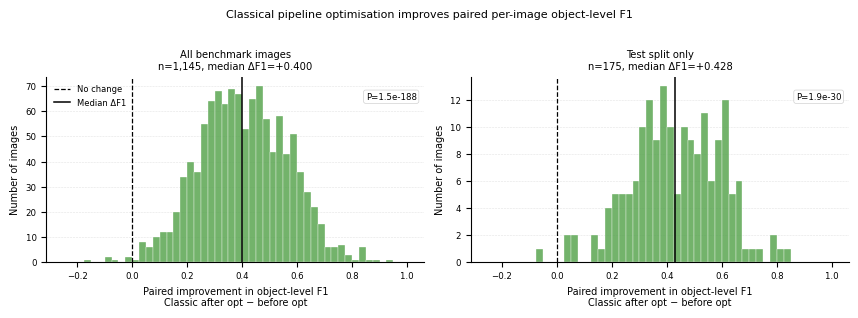

  Saved: fig3_classical_wilcoxon_delta.svg
  Saved: fig3_classical_wilcoxon_delta.png


In [2]:
# ── §1: Paired Wilcoxon signed-rank test for classical before/after F1 ──────
# Source:
#   outputs/classical_bfr_aft/or_matching/per_image_metrics.csv
#
# Outputs:
#   source_fig3_wilcoxon.csv
#   source_fig3_classical_wilcoxon_delta.csv
#   fig3_classical_wilcoxon_delta.{svg,png}
#
# Note:
#   This section intentionally uses paired per-image F1 because the Wilcoxon
#   signed-rank test requires paired image-level observations. Benchmark
#   comparison figures elsewhere use pooled object-level F1.

bfra_path = CLASSICAL_BFRAFT / 'per_image_metrics.csv'
require_file(
    bfra_path,
    label='Classical before/after per-image metrics',
)

bfra = pd.read_csv(bfra_path)

require_columns(
    bfra,
    ['model'],
    label='classical before/after per-image metrics',
)

uid_col = find_metric_column(
    bfra,
    candidates=['unique_id', 'uid', 'image_id', 'id'],
    label='image identifier column',
)

f1_col = find_metric_column(
    bfra,
    candidates=['obj_f1', 'object_f1', 'f1'],
    label='per-image object-level F1 column',
)

has_split = 'split' in bfra.columns

bfra = bfra.copy()
bfra['model'] = bfra['model'].apply(canonical_model_name)
bfra[f1_col] = pd.to_numeric(bfra[f1_col], errors='coerce')

models_needed = ['Classic (before opt)', 'Classic (after opt)']
models_present = sorted(bfra['model'].dropna().unique().tolist())

print(f'Loaded {len(bfra):,} per-image rows from: {bfra_path}')
print(f'Image identifier column: {uid_col}')
print(f'F1 column: {f1_col}')
print(f'Split column present: {has_split}')
print(f'Models present: {models_present}')

missing_models = [m for m in models_needed if m not in models_present]
if missing_models:
    raise ValueError(
        f'Missing required model(s) for paired test: {missing_models}. '
        f'Models present after canonicalization: {models_present}'
    )


def build_paired_table(df, subset_label):
    """Return paired before/after per-image F1 table for one subset."""
    if df.empty:
        raise ValueError(f'No rows available for subset: {subset_label}')

    paired = (
        df[df['model'].isin(models_needed)]
        .pivot_table(
            index=uid_col,
            columns='model',
            values=f1_col,
            aggfunc='first',
        )
        .reindex(columns=models_needed)
        .dropna(how='any')
    )

    if paired.empty:
        raise ValueError(
            f'No paired before/after images remained for subset: {subset_label}'
        )

    paired = paired.rename(
        columns={
            'Classic (before opt)': 'f1_before',
            'Classic (after opt)': 'f1_after',
        }
    )

    paired['delta_after_minus_before'] = paired['f1_after'] - paired['f1_before']
    paired['subset'] = subset_label

    return paired.reset_index()


def summarize_paired_wilcoxon(paired, subset_label):
    """Compute paired before/after summary and Wilcoxon statistics."""
    before = paired['f1_before'].astype(float).to_numpy()
    after = paired['f1_after'].astype(float).to_numpy()
    delta = after - before

    n_pairs = int(len(paired))
    n_positive = int((delta > 0).sum())
    n_negative = int((delta < 0).sum())
    n_zero = int((delta == 0).sum())

    if n_positive + n_negative == 0:
        w_stat_two = np.nan
        p_two = np.nan
        w_stat_greater = np.nan
        p_greater = np.nan
    else:
        w_stat_two, p_two = stats.wilcoxon(
            after,
            before,
            alternative='two-sided',
            zero_method='wilcox',
            correction=False,
        )

        w_stat_greater, p_greater = stats.wilcoxon(
            after,
            before,
            alternative='greater',
            zero_method='wilcox',
            correction=False,
        )

    return {
        'subset': subset_label,
        'n_paired_images': n_pairs,
        'n_after_greater_than_before': n_positive,
        'n_after_less_than_before': n_negative,
        'n_equal_pairs': n_zero,
        'median_obj_f1_before': float(np.median(before)),
        'median_obj_f1_after': float(np.median(after)),
        'mean_obj_f1_before': float(np.mean(before)),
        'mean_obj_f1_after': float(np.mean(after)),
        'median_paired_delta_after_minus_before': float(np.median(delta)),
        'mean_paired_delta_after_minus_before': float(np.mean(delta)),
        'wilcoxon_statistic_W_two_sided': float(w_stat_two),
        'p_two_sided': float(p_two),
        'wilcoxon_statistic_W_greater': float(w_stat_greater),
        'p_greater_after_minus_before': float(p_greater),
    }


paired_tables = []
summary_rows = []

# Full benchmark set.
paired_all = build_paired_table(bfra, subset_label='all_images')
paired_tables.append(paired_all)
summary_rows.append(
    summarize_paired_wilcoxon(paired_all, subset_label='all_images')
)

# Held-out test split, if split labels are available.
if has_split:
    test_rows = bfra[bfra['split'].astype(str).str.lower() == 'test'].copy()
    paired_test = build_paired_table(test_rows, subset_label='test_only')
    paired_tables.append(paired_test)
    summary_rows.append(
        summarize_paired_wilcoxon(paired_test, subset_label='test_only')
    )
else:
    print('Warning: no split column found. Test-only Wilcoxon summary was skipped.')

wilcoxon_summary = pd.DataFrame(summary_rows)
paired_delta_df = pd.concat(paired_tables, ignore_index=True)

source_summary_csv = OUT_DIR / 'source_fig3_wilcoxon.csv'
source_delta_csv = OUT_DIR / 'source_fig3_classical_wilcoxon_delta.csv'

wilcoxon_summary.to_csv(source_summary_csv, index=False)
paired_delta_df.to_csv(source_delta_csv, index=False)

# Display a readable version without rounding very small P values to 0.0.
display_df = wilcoxon_summary.copy()
for col in ['p_two_sided', 'p_greater_after_minus_before']:
    display_df[col] = display_df[col].map(lambda x: f'{x:.3e}' if pd.notna(x) else 'NA')

numeric_cols = [
    'median_obj_f1_before',
    'median_obj_f1_after',
    'mean_obj_f1_before',
    'mean_obj_f1_after',
    'median_paired_delta_after_minus_before',
    'mean_paired_delta_after_minus_before',
]
display_df[numeric_cols] = display_df[numeric_cols].round(4)

display(display_df)

print(f'Saved Wilcoxon summary: {source_summary_csv}')
print(f'Saved paired delta source data: {source_delta_csv}')

for row in wilcoxon_summary.itertuples(index=False):
    print(
        f'{row.subset}: '
        f'n={row.n_paired_images:,}; '
        f'after > before in {row.n_after_greater_than_before:,} images; '
        f'after < before in {row.n_after_less_than_before:,} images; '
        f'mean ΔF1={row.mean_paired_delta_after_minus_before:+.3f}; '
        f'median ΔF1={row.median_paired_delta_after_minus_before:+.3f}; '
        f'two-sided Wilcoxon P={row.p_two_sided:.3g}; '
        f'one-sided after > before P={row.p_greater_after_minus_before:.3g}'
    )


# ── Visual summary: paired improvement distribution ─────────────────────────
subsets_to_plot = ['all_images']
if 'test_only' in set(paired_delta_df['subset']):
    subsets_to_plot.append('test_only')

fig, axes = plt.subplots(
    1,
    len(subsets_to_plot),
    figsize=(4.3 * len(subsets_to_plot), 3.0),
    squeeze=False,
)

bins = np.linspace(-0.25, 1.0, 51)

for ax, subset_name in zip(axes.flatten(), subsets_to_plot):
    sub = paired_delta_df[paired_delta_df['subset'] == subset_name].copy()
    delta = sub['delta_after_minus_before'].astype(float).to_numpy()

    summary = wilcoxon_summary[
        wilcoxon_summary['subset'] == subset_name
    ].iloc[0]

    ax.hist(
        delta,
        bins=bins,
        color=MODEL_COLORS['Classic (after opt)'],
        alpha=0.82,
        edgecolor='white',
        linewidth=0.3,
    )

    ax.axvline(
        0,
        color='black',
        linestyle='--',
        linewidth=0.9,
        label='No change',
    )

    ax.axvline(
        np.median(delta),
        color='black',
        linestyle='-',
        linewidth=1.1,
        label='Median ΔF1',
    )

    pretty_subset = {
        'all_images': 'All benchmark images',
        'test_only': 'Test split only',
    }.get(subset_name, subset_name)

    ax.set_title(
        (
            f'{pretty_subset}\n'
            f'n={int(summary["n_paired_images"]):,}, '
            f'median ΔF1={summary["median_paired_delta_after_minus_before"]:+.3f}'
        ),
        fontsize=7.2,
    )

    ax.set_xlabel(
        'Paired improvement in object-level F1\n'
        'Classic after opt − before opt'
    )
    ax.set_ylabel('Number of images')

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.4,
        alpha=0.35,
    )
    ax.set_axisbelow(True)

    ax.text(
        0.98,
        0.92,
        f'P={summary["p_two_sided"]:.1e}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=6.2,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='0.8',
            linewidth=0.5,
            alpha=0.9,
        ),
    )

axes.flatten()[0].legend(
    frameon=False,
    fontsize=6.0,
    loc='upper left',
)

fig.suptitle(
    'Classical pipeline optimisation improves paired per-image object-level F1',
    fontsize=8.0,
    y=1.03,
)

fig.tight_layout()

display(fig)
save_fig(fig, 'fig3_classical_wilcoxon_delta')
plt.close(fig)

### Interpretation

The paired before/after analysis confirms that Bayesian optimisation produced a
large and consistent improvement in the classical baseline.

Across all 1,145 benchmark images, object-level F1 increased for 1,138 images,
decreased for only 6 images, and was unchanged for 1 image. The median paired
improvement was +0.400 F1, with a two-sided Wilcoxon signed-rank P value of
1.5 × 10⁻¹⁸⁸.

The same pattern held on the held-out test split. Among the 175 test images,
174 improved after optimisation and only 1 decreased. The median paired
improvement on the test split was +0.428 F1, with a two-sided Wilcoxon
P value of 1.9 × 10⁻³⁰.

This section uses paired per-image F1 values because the Wilcoxon signed-rank
test requires one paired observation per image. The result shows that the
classical optimisation effect is not driven by a small number of outlier images;
instead, the improvement is systematic across nearly the entire benchmark and
remains present on the fully held-out test split.

## §2 — Gold-standard count disclosure across the full resource

The benchmark uses `ecDNA_gt` as the locked gold-standard count. This value is
defined as the number of 8-connected components in the rendered GS mask after
filtering components smaller than 3 pixels. This is the same object definition
used by the matching framework.

Here we disclose how this mask-derived count relates to the original coordinate
count, `coord_count_npy`, across the full 2,986-image resource. The two values
are expected to be highly concordant but not always identical. When nearby
coordinate-rendered foci touch after GS-mask rendering, they can merge into one
connected component. In those cases, the connected-component count can be
slightly smaller than the raw coordinate count.

Each panel shows one cell line. The dashed diagonal is the identity line.
Points on the diagonal have identical coordinate and connected-component counts.
Points below the diagonal indicate images where the connected-component count is
lower than the coordinate count, usually because nearby rendered foci merged in
the binary GS mask.

This disclosure is included to make the gold-standard counting convention
transparent. It does not change the benchmark definition: all object matching
and count-error metrics use the locked `ecDNA_gt` connected-component count.

Outputs:

- `figS_gt_count_disclosure.{svg,png}`
- `source_figS_gt_count_disclosure.csv`
- `source_figS_gt_count_disclosure_long.csv`nt_disclosure_long.csv`

Loaded full count table: 2,986 rows
Rows with valid coordinate and GT counts: 2,986
Cell lines present: ['NCI-H2170', 'SNU16', 'COLO320DM', 'NCI-H716', 'SUM159PT']


,cell_line,n_images,n_equal_counts,n_coord_count_larger_than_ecDNA_gt,n_ecDNA_gt_larger_than_coord_count,percent_equal_counts,median_coord_count_npy,median_ecDNA_gt,median_abs_delta,mean_abs_delta,max_abs_delta,pearson_r
0,NCI-H2170,1891,1028,863,0,54.363,159.0,157.0,0.0,2.545,228.0,0.999
1,SNU16,273,90,183,0,32.967,274.0,271.0,2.0,3.597,96.0,0.999
2,COLO320DM,225,207,18,0,92.000,9.0,9.0,0.0,0.138,12.0,1.000
3,NCI-H716,139,85,54,0,61.151,180.0,179.0,0.0,2.180,33.0,0.998
4,SUM159PT,458,385,73,0,84.061,4.0,4.0,0.0,0.181,8.0,0.994


Saved summary source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_figS_gt_count_disclosure.csv
Saved long-form source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_figS_gt_count_disclosure_long.csv


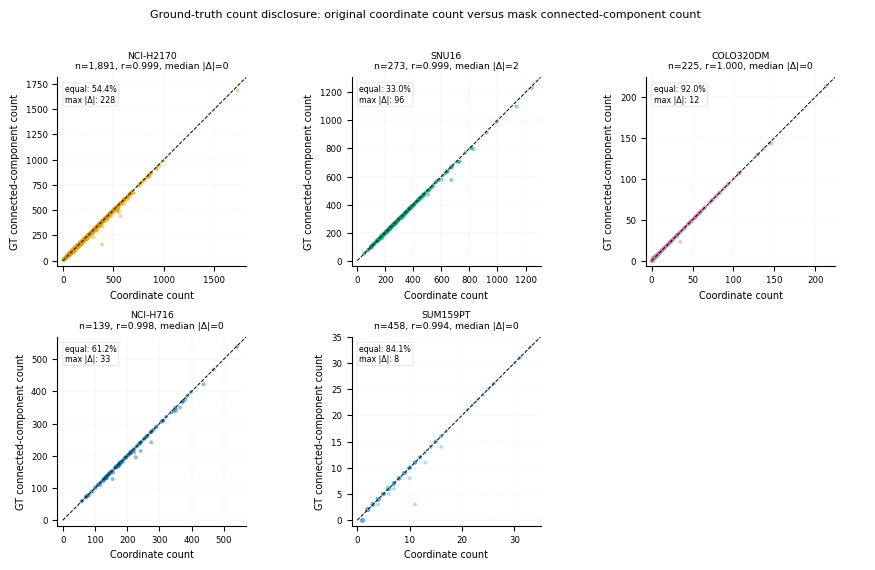

  Saved: figS_gt_count_disclosure.svg
  Saved: figS_gt_count_disclosure.png


In [3]:
# ── §2: GS-count disclosure scatter across the full resource ────────────────
# Source:
#   release/manifests/full_counts_master.csv
#
# Outputs:
#   figS_gt_count_disclosure.{svg,png}
#   source_figS_gt_count_disclosure.csv
#   source_figS_gt_count_disclosure_long.csv

fc_path = MANIFESTS / 'full_counts_master.csv'
require_file(fc_path, label='Full counts master')

fc = pd.read_csv(fc_path)

require_columns(
    fc,
    ['cell_line', 'coord_count_npy', 'ecDNA_gt'],
    label='full_counts_master.csv',
)

uid_col = find_metric_column(
    fc,
    candidates=['unique_id', 'uid', 'image_id', 'id'],
    label='image identifier column',
)

fc = fc.copy()
fc['cell_line'] = fc['cell_line'].apply(canonical_cell_line)
fc['coord_count_npy'] = pd.to_numeric(fc['coord_count_npy'], errors='coerce')
fc['ecDNA_gt'] = pd.to_numeric(fc['ecDNA_gt'], errors='coerce')

fc_valid = fc.dropna(
    subset=['cell_line', 'coord_count_npy', 'ecDNA_gt']
).copy()

fc_valid['delta_coord_minus_gt'] = (
    fc_valid['coord_count_npy'] - fc_valid['ecDNA_gt']
)
fc_valid['abs_delta'] = fc_valid['delta_coord_minus_gt'].abs()

full_resource_cl_order = [
    'NCI-H2170',
    'SNU16',
    'COLO320DM',
    'NCI-H716',
    'SUM159PT',
]

cells_present = [
    cl for cl in full_resource_cl_order
    if cl in set(fc_valid['cell_line'])
]

extra_cells = sorted(set(fc_valid['cell_line']) - set(cells_present))
cells_present = cells_present + extra_cells

if not cells_present:
    raise ValueError('No valid cell lines found in full_counts_master.csv.')

print(f'Loaded full count table: {fc.shape[0]:,} rows')
print(f'Rows with valid coordinate and GS counts: {fc_valid.shape[0]:,}')
print(f'Cell lines present: {cells_present}')

summary_rows = []

for cl in cells_present:
    sub = fc_valid[fc_valid['cell_line'] == cl].copy()

    x = sub['coord_count_npy'].to_numpy(dtype=float)
    y = sub['ecDNA_gt'].to_numpy(dtype=float)
    delta = x - y

    n = int(len(sub))
    n_equal = int((delta == 0).sum())
    n_coord_larger = int((delta > 0).sum())
    n_gt_larger = int((delta < 0).sum())

    pearson_r = (
        float(np.corrcoef(x, y)[0, 1])
        if n >= 2 and np.std(x) > 0 and np.std(y) > 0
        else np.nan
    )

    summary_rows.append({
        'cell_line': cl,
        'n_images': n,
        'n_equal_counts': n_equal,
        'n_coord_count_larger_than_ecDNA_gt': n_coord_larger,
        'n_ecDNA_gt_larger_than_coord_count': n_gt_larger,
        'percent_equal_counts': 100 * n_equal / n if n > 0 else np.nan,
        'median_coord_count_npy': float(np.median(x)) if n > 0 else np.nan,
        'median_ecDNA_gt': float(np.median(y)) if n > 0 else np.nan,
        'median_abs_delta': float(np.median(np.abs(delta))) if n > 0 else np.nan,
        'mean_abs_delta': float(np.mean(np.abs(delta))) if n > 0 else np.nan,
        'max_abs_delta': float(np.max(np.abs(delta))) if n > 0 else np.nan,
        'pearson_r': pearson_r,
    })

summary_df = pd.DataFrame(summary_rows)

source_summary_csv = OUT_DIR / 'source_figS_gt_count_disclosure.csv'
summary_df.to_csv(source_summary_csv, index=False)

long_cols = [
    uid_col,
    'cell_line',
    'coord_count_npy',
    'ecDNA_gt',
    'delta_coord_minus_gt',
    'abs_delta',
]

if 'split' in fc_valid.columns:
    long_cols.insert(2, 'split')

source_long_csv = OUT_DIR / 'source_figS_gt_count_disclosure_long.csv'
fc_valid[long_cols].to_csv(source_long_csv, index=False)

display(summary_df.round(3))

print(f'Saved summary source data: {source_summary_csv}')
print(f'Saved long-form source data: {source_long_csv}')


# ── Plot: coordinate count versus connected-component GS count ──────────────
n_panels = len(cells_present)
n_cols = 3
n_rows = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.0 * n_cols, 2.75 * n_rows),
    squeeze=False,
)

axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, cells_present):
    sub = fc_valid[fc_valid['cell_line'] == cl].copy()

    x = sub['coord_count_npy'].to_numpy(dtype=float)
    y = sub['ecDNA_gt'].to_numpy(dtype=float)

    color = CELL_LINE_COLORS.get(cl, '#777777')

    lim_hi = max(float(np.nanmax(x)), float(np.nanmax(y)), 1.0)
    lim_hi = np.ceil(lim_hi * 1.05)

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.45,
        color=color,
        edgecolor='none',
        rasterized=True,
    )

    ax.plot(
        [0, lim_hi],
        [0, lim_hi],
        color='black',
        linewidth=0.7,
        linestyle='--',
        label='Identity',
    )

    ax.set_xlim(-0.03 * lim_hi, lim_hi)
    ax.set_ylim(-0.03 * lim_hi, lim_hi)
    ax.set_aspect('equal', adjustable='box')

    row = summary_df[summary_df['cell_line'] == cl].iloc[0]

    ax.set_title(
        (
            f'{cl}\n'
            f'n={int(row["n_images"]):,}, '
            f'r={row["pearson_r"]:.3f}, '
            f'median |Δ|={row["median_abs_delta"]:.0f}'
        ),
        fontsize=6.7,
    )

    ax.set_xlabel('Coordinate count')
    ax.set_ylabel('GS connected-component count')

    ax.grid(
        linestyle='--',
        linewidth=0.35,
        alpha=0.30,
    )
    ax.set_axisbelow(True)

    ax.text(
        0.04,
        0.96,
        (
            f'equal: {row["percent_equal_counts"]:.1f}%\n'
            f'max |Δ|: {row["max_abs_delta"]:.0f}'
        ),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=5.7,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='0.85',
            linewidth=0.5,
            alpha=0.88,
        ),
    )

for ax in axes_flat[n_panels:]:
    ax.axis('off')

fig.suptitle(
    (
        'Gold-standard count disclosure: original coordinate count versus '
        'mask connected-component count'
    ),
    fontsize=8.0,
    y=1.02,
)

fig.tight_layout()

display(fig)
save_fig(fig, 'figS_gt_count_disclosure')
plt.close(fig)

### Interpretation

The GS-count disclosure confirms that the mask-derived benchmark count,
`ecDNA_gt`, is highly concordant with the original coordinate count across the
full 2,986-image resource. Pearson correlation was at least 0.994 for every cell
line.

Most images had identical or near-identical counts. The median absolute
difference was 0 for NCI-H2170, COLO320DM, NCI-H716, and SUM159PT, and 2 for
SNU16. When discrepancies occurred, `coord_count_npy` was always greater than
or equal to `ecDNA_gt`. This is the expected direction: nearby coordinate-rendered
foci can touch after rendering and become one 8-connected component in the GS
mask.

This result supports using the connected-component count as the benchmark
target. It is highly consistent with the original coordinate annotations while
also matching the exact object definition used for mask-based prediction
evaluation.aluation.

## §3 — Per-cell-line object-level F1 heatmaps

This section summarises model performance by cell line using annotated
heatmaps. The goal is to provide a compact visual version of the grouped
cell-line comparisons from Notebook 03.

To keep Notebook 05 consistent with the benchmark figures, F1 is computed from
pooled object counts within each model × cell-line group:

`F1 = 2 × TP / (2 × TP + FP + FN)`

This is the same pooled object-level F1 convention used for the frozen
benchmark summaries. It is different from the paired per-image F1 used only in
§1 for the Wilcoxon signed-rank test.

We generate two heatmaps:

1. **Six-model benchmark heatmap.**  
   Pooled object-level F1 for the six main benchmarked models across the full
   1,145-image benchmark.

2. **Seven-condition test-split heatmap.**  
   Pooled object-level F1 on the held-out test split, adding
   `Classic (before opt)` so the Bayesian-optimisation gain can be inspected by
   cell line.

Both panels use the same cell-line order, model naming, and colour scale
(`viridis`, fixed to 0–1). Each cell is annotated with F1 to three decimal
places.

Outputs:

- `fig6_f1_by_cell_line_heatmap.{svg,png}`
- `source_fig6_f1_by_cell_line_heatmap.csv`
- `source_fig6_f1_by_cell_line_heatmap_long.csv`
- `figS_f1_by_cell_line_heatmap_7row.{svg,png}`
- `source_figS_f1_by_cell_line_heatmap_7row.csv`
- `source_figS_f1_by_cell_line_heatmap_7row_long.csv`_line_heatmap_7row_long.csv`

Loaded frozen benchmark metrics: 6,870 rows
F1 convention: pooled object-level F1 from TP/FP/FN
Models present: ['Classic (after opt)', 'Label Engine', 'MIA', 'ecCount (peaks)', 'ecCount (threshold mask)', 'ecSeg']
Cell lines present: ['COLO320DM', 'NCI-H2170', 'NCI-H716', 'SNU16']

Six-model full-benchmark pooled-F1 heatmap matrix:


cell_line,NCI-H2170,SNU16,COLO320DM,NCI-H716
model,,,,
ecCount (peaks),0.944,0.932,0.915,0.952
ecCount (threshold mask),0.917,0.913,0.907,0.939
Label Engine,0.878,0.569,0.692,0.710
MIA,0.852,0.497,0.766,0.724
Classic (after opt),0.750,0.858,0.825,0.901
ecSeg,0.529,0.112,0.224,0.316


Saved matrix source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig6_f1_by_cell_line_heatmap.csv
Saved long-form source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig6_f1_by_cell_line_heatmap_long.csv


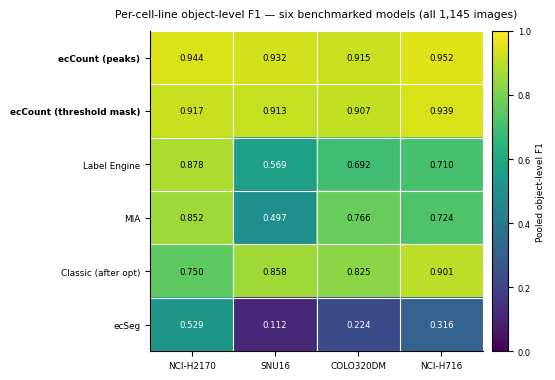

  Saved: fig6_f1_by_cell_line_heatmap.svg
  Saved: fig6_f1_by_cell_line_heatmap.png

Seven-condition test-split pooled-F1 heatmap matrix:


cell_line,NCI-H2170,SNU16,COLO320DM,NCI-H716
model,,,,
ecCount (peaks),0.941,0.931,0.886,0.949
ecCount (threshold mask),0.915,0.915,0.876,0.940
Label Engine,0.878,0.591,0.701,0.599
MIA,0.868,0.519,0.754,0.614
Classic (after opt),0.751,0.845,0.825,0.904
Classic (before opt),0.335,0.427,0.329,0.519
ecSeg,0.581,0.155,0.160,0.185


Saved matrix source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_figS_f1_by_cell_line_heatmap_7row.csv
Saved long-form source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_figS_f1_by_cell_line_heatmap_7row_long.csv


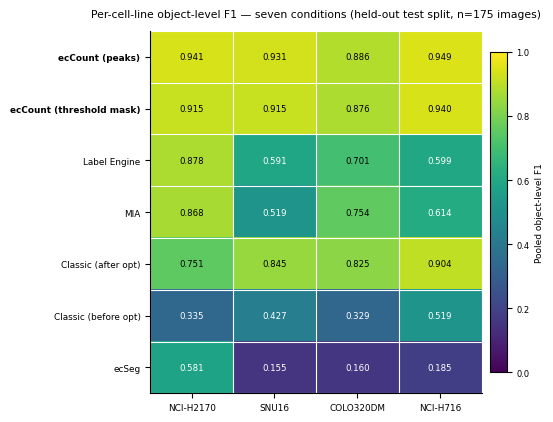

  Saved: figS_f1_by_cell_line_heatmap_7row.svg
  Saved: figS_f1_by_cell_line_heatmap_7row.png


In [4]:
# ── §3: Per-cell-line pooled object-level F1 heatmaps ───────────────────────
# Sources:
#   release/frozen_results/or_matching/per_image_metrics.csv
#   outputs/classical_bfr_aft/or_matching/per_image_metrics.csv
#
# Outputs:
#   fig6_f1_by_cell_line_heatmap.{svg,png}
#   source_fig6_f1_by_cell_line_heatmap.csv
#   source_fig6_f1_by_cell_line_heatmap_long.csv
#   figS_f1_by_cell_line_heatmap_7row.{svg,png}
#   source_figS_f1_by_cell_line_heatmap_7row.csv
#   source_figS_f1_by_cell_line_heatmap_7row_long.csv
#
# F1 convention:
#   Pooled object-level F1 within each group:
#   F1 = 2 * sum(TP) / [2 * sum(TP) + sum(FP) + sum(FN)].
#
# This intentionally avoids averaging per-image F1 here.

benchmark_pim_path = FROZEN_OR / 'per_image_metrics.csv'
require_file(
    benchmark_pim_path,
    label='Frozen OR-matching per-image metrics',
)

benchmark_pim = pd.read_csv(benchmark_pim_path)

require_columns(
    benchmark_pim,
    ['model', 'cell_line', 'obj_tp', 'obj_fp', 'obj_fn'],
    label='frozen OR-matching per-image metrics',
)

bench_uid_col = find_metric_column(
    benchmark_pim,
    candidates=['unique_id', 'uid', 'image_id', 'id'],
    label='benchmark image identifier column',
)

benchmark_pim = benchmark_pim.copy()
benchmark_pim['model'] = benchmark_pim['model'].apply(canonical_model_name)
benchmark_pim['cell_line'] = benchmark_pim['cell_line'].apply(canonical_cell_line)

for col in ['obj_tp', 'obj_fp', 'obj_fn']:
    benchmark_pim[col] = pd.to_numeric(benchmark_pim[col], errors='coerce')

benchmark_pim = benchmark_pim.dropna(
    subset=['model', 'cell_line', 'obj_tp', 'obj_fp', 'obj_fn']
).copy()

print(f'Loaded frozen benchmark metrics: {benchmark_pim.shape[0]:,} rows')
print('F1 convention: pooled object-level F1 from TP/FP/FN')
print(f'Models present: {sorted(benchmark_pim["model"].unique())}')
print(f'Cell lines present: {sorted(benchmark_pim["cell_line"].unique())}')


def plot_f1_heatmap(matrix_df, title, basename, cbar_label='Pooled object-level F1'):
    """Plot an annotated F1 heatmap with a fixed 0–1 colour scale."""
    fig_h = max(2.6, 0.42 * len(matrix_df.index) + 1.3)
    fig_w = max(4.8, 0.78 * len(matrix_df.columns) + 2.4)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    values = matrix_df.values.astype(float)

    im = ax.imshow(
        values,
        cmap='viridis',
        vmin=0,
        vmax=1,
        aspect='auto',
    )

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_xticklabels(matrix_df.columns, fontsize=6.4)

    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_yticklabels(matrix_df.index, fontsize=6.4)

    ax.set_title(title, fontsize=7.8, pad=10)

    ax.set_xticks(np.arange(-0.5, len(matrix_df.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(matrix_df.index), 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.8)
    ax.tick_params(which='minor', bottom=False, left=False)

    cmap = plt.get_cmap('viridis')

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]

            if not np.isfinite(v):
                ax.text(
                    j,
                    i,
                    'NA',
                    ha='center',
                    va='center',
                    fontsize=6.2,
                    color='white',
                )
                continue

            r, g, b, _ = cmap(v)
            luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
            text_color = 'black' if luminance > 0.55 else 'white'

            ax.text(
                j,
                i,
                f'{v:.3f}',
                ha='center',
                va='center',
                fontsize=6.2,
                color=text_color,
            )

    for tick_label in ax.get_yticklabels():
        if tick_label.get_text().startswith('ecCount'):
            tick_label.set_fontweight('bold')

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.045,
        pad=0.025,
    )
    cbar.set_label(cbar_label, fontsize=6.5)
    cbar.ax.tick_params(labelsize=6.0)

    fig.tight_layout()

    display(fig)
    save_fig(fig, basename)
    plt.close(fig)


# ── §3a: Six-model pooled F1 heatmap across the full benchmark ──────────────
six_model_df = benchmark_pim[
    benchmark_pim['model'].isin(MODEL_ORDER_6)
].copy()

if six_model_df.empty:
    raise ValueError(
        'No rows remained for the six-model benchmark heatmap after filtering.'
    )

n_all_images = six_model_df[bench_uid_col].nunique()

six_long = pooled_object_f1(
    six_model_df,
    group_cols=['model', 'cell_line'],
    output_col='object_f1',
)

# Keep source columns explicit and manuscript-friendly.
six_long = six_long[
    ['model', 'cell_line', 'n_images', 'tp', 'fp', 'fn', 'object_f1']
].copy()

mat_6 = (
    six_long
    .pivot_table(
        index='model',
        columns='cell_line',
        values='object_f1',
        aggfunc='first',
    )
    .reindex(index=MODEL_ORDER_6, columns=CL_ORDER)
)

source_6_matrix_csv = OUT_DIR / 'source_fig6_f1_by_cell_line_heatmap.csv'
source_6_long_csv = OUT_DIR / 'source_fig6_f1_by_cell_line_heatmap_long.csv'

mat_6.to_csv(source_6_matrix_csv)
six_long.to_csv(source_6_long_csv, index=False)

print('\nSix-model full-benchmark pooled-F1 heatmap matrix:')
display(mat_6.round(3))
print(f'Saved matrix source data: {source_6_matrix_csv}')
print(f'Saved long-form source data: {source_6_long_csv}')

plot_f1_heatmap(
    mat_6,
    title=(
        'Per-cell-line object-level F1 — six benchmarked models '
        f'(all {n_all_images:,} images)'
    ),
    basename='fig6_f1_by_cell_line_heatmap',
)


# ── §3b: Seven-condition pooled F1 heatmap on held-out test split ───────────
if 'split' not in benchmark_pim.columns:
    raise KeyError(
        'Frozen benchmark per-image metrics do not contain a split column; '
        'cannot construct the test-split heatmap.'
    )

test_six_df = benchmark_pim[
    (benchmark_pim['split'].astype(str).str.lower() == 'test')
    & (benchmark_pim['model'].isin(MODEL_ORDER_6))
].copy()

if test_six_df.empty:
    raise ValueError(
        'No test-split rows remained for the six benchmark models.'
    )

bfra_path = CLASSICAL_BFRAFT / 'per_image_metrics.csv'
require_file(
    bfra_path,
    label='Classical before/after per-image metrics',
)

bfra = pd.read_csv(bfra_path)

require_columns(
    bfra,
    ['model', 'cell_line', 'split', 'obj_tp', 'obj_fp', 'obj_fn'],
    label='classical before/after per-image metrics',
)

bfra = bfra.copy()
bfra['model'] = bfra['model'].apply(canonical_model_name)
bfra['cell_line'] = bfra['cell_line'].apply(canonical_cell_line)

for col in ['obj_tp', 'obj_fp', 'obj_fn']:
    bfra[col] = pd.to_numeric(bfra[col], errors='coerce')

before_test_df = bfra[
    (bfra['split'].astype(str).str.lower() == 'test')
    & (bfra['model'] == 'Classic (before opt)')
].copy()

before_test_df = before_test_df.dropna(
    subset=['model', 'cell_line', 'obj_tp', 'obj_fp', 'obj_fn']
).copy()

if before_test_df.empty:
    raise ValueError(
        'No held-out test rows were found for Classic (before opt) in '
        f'{bfra_path}.'
    )

test_six_long = pooled_object_f1(
    test_six_df,
    group_cols=['model', 'cell_line'],
    output_col='object_f1',
)

before_test_long = pooled_object_f1(
    before_test_df,
    group_cols=['model', 'cell_line'],
    output_col='object_f1',
)

seven_test_long = pd.concat(
    [test_six_long, before_test_long],
    ignore_index=True,
)

seven_test_long = seven_test_long[
    ['model', 'cell_line', 'n_images', 'tp', 'fp', 'fn', 'object_f1']
].copy()

mat_7 = (
    seven_test_long
    .pivot_table(
        index='model',
        columns='cell_line',
        values='object_f1',
        aggfunc='first',
    )
    .reindex(index=MODEL_ORDER_7, columns=CL_ORDER)
)

n_test_images = test_six_df[bench_uid_col].nunique()

source_7_matrix_csv = OUT_DIR / 'source_figS_f1_by_cell_line_heatmap_7row.csv'
source_7_long_csv = OUT_DIR / 'source_figS_f1_by_cell_line_heatmap_7row_long.csv'

mat_7.to_csv(source_7_matrix_csv)
seven_test_long.to_csv(source_7_long_csv, index=False)

print('\nSeven-condition test-split pooled-F1 heatmap matrix:')
display(mat_7.round(3))
print(f'Saved matrix source data: {source_7_matrix_csv}')
print(f'Saved long-form source data: {source_7_long_csv}')

plot_f1_heatmap(
    mat_7,
    title=(
        'Per-cell-line object-level F1 — seven conditions '
        f'(held-out test split, n={n_test_images:,} images)'
    ),
    basename='figS_f1_by_cell_line_heatmap_7row',
)

### Interpretation

The per-cell-line heatmaps show that ecCount maintains high pooled
object-level F1 across all four benchmarked cell lines. The peak-based ecCount
output achieved the highest F1 in every cell line in the full benchmark, ranging
from 0.915 in COLO320DM to 0.952 in NCI-H716. The threshold-mask variant was
consistently second-best, ranging from 0.907 to 0.939. This indicates that most
of the performance gain is already present in the learned probability map, with
peak extraction providing an additional improvement.

The full-benchmark heatmap also shows where the non-ecCount baselines vary by
cell line. Label Engine performed strongly on NCI-H2170 but dropped on SNU16,
COLO320DM, and NCI-H716. MIA showed a similar pattern, with relatively strong
performance on NCI-H2170 and COLO320DM but weaker performance on SNU16.
The optimized classical pipeline performed especially well on SNU16 and
NCI-H716, but remained below ecCount overall. ecSeg had the lowest F1 in every
cell line.

The seven-condition test-split heatmap confirms that Bayesian optimisation
substantially improved the classical pipeline in every cell line. Test-split
pooled F1 increased from 0.335 to 0.751 in NCI-H2170, from 0.427 to 0.845 in
SNU16, from 0.329 to 0.825 in COLO320DM, and from 0.519 to 0.904 in NCI-H716.
Thus, the classical optimisation effect is not driven by one cell line; it is a
broad improvement across the benchmark.

Overall, this section supports two conclusions: ecCount is the strongest and
most consistent model across cell lines, and the classical optimisation step
produces a reproducible improvement across all held-out cell-line groups.

## §4 — Global performance summary: full benchmark and held-out test split

This section consolidates three complementary metrics for the six main
benchmark models:

1. **Pooled object-level F1** — computed from summed object-level TP, FP, and
   FN within each model and subset:

   `F1 = 2 × TP / (2 × TP + FP + FN)`

2. **Pixel-level Dice** — read from the frozen pooled benchmark summaries.

3. **Count MAE** — computed from per-image predicted and GS counts.

We report each metric in two scopes:

- **All benchmark images:** the full 1,145-image benchmark.
- **Held-out test split:** the 175 images not used for training or
  classical-parameter selection.

The same model order is used in both rows, ranked by pooled object-level F1 on
the full benchmark. This makes it clear whether the global ranking is preserved
in the held-out test set.

This section intentionally does not use mean per-image F1. The only section in
Notebook 05 that uses paired per-image F1 is §1, where paired image-level values
are required for the Wilcoxon signed-rank test.

Outputs:

- `fig6_global_performance_bars.{svg,png}`
- `source_fig6_global_performance_bars.csv`csv`rformance_bars.csv`

Predicted count column: pred_count
GT count column: gt_count
Overall pixel Dice column: pix_dice
Split pixel Dice column: pix_dice
F1 convention: pooled object-level F1 from TP/FP/FN
Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig6_global_performance_bars.csv


,subset,model,n_images,tp,fp,fn,object_f1,pixel_dice,count_mae,count_bias
0,all_images,ecCount (peaks),1145,211160,9130,16879,0.9420,0.3205,13.1118,0.3555
1,all_images,ecCount (threshold mask),1145,200818,8923,27221,0.9174,0.3109,18.0769,-11.4410
2,all_images,Label Engine,1145,172365,17639,55674,0.8246,0.2475,36.0279,-28.7633
3,all_images,MIA,1145,161874,14615,66165,0.8003,0.2063,46.9520,-40.6201
4,all_images,Classic (after opt),1145,162540,27720,65499,0.7771,0.1261,44.9240,-24.2847
5,all_images,ecSeg,1145,73746,16297,154293,0.4637,0.1460,121.4865,-118.4681
6,test_only,ecCount (peaks),175,31137,1545,2491,0.9391,0.3100,13.3086,1.8800
7,test_only,ecCount (threshold mask),175,29674,1512,3954,0.9157,0.3018,17.6171,-9.1029
8,test_only,Label Engine,175,25498,2689,8130,0.8250,0.2474,34.3657,-26.8686
9,test_only,MIA,175,24482,2136,9146,0.8127,0.2172,40.3943,-35.7429


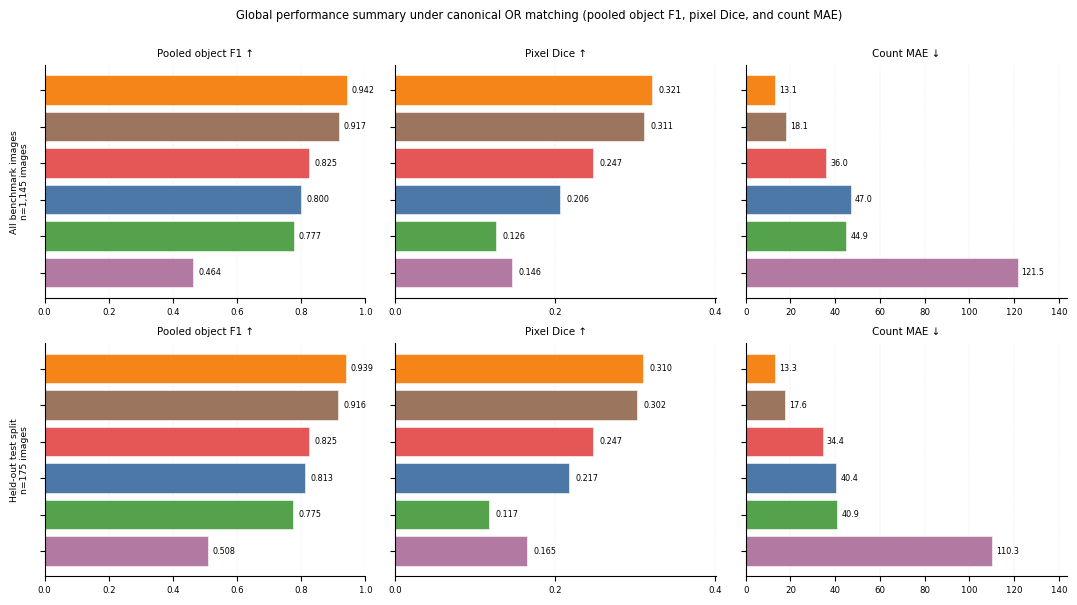

  Saved: fig6_global_performance_bars.svg
  Saved: fig6_global_performance_bars.png


In [5]:
# ── §4: Global performance summary, full benchmark and test split ───────────
# Sources:
#   release/frozen_results/or_matching/per_image_metrics.csv
#   release/frozen_results/or_matching/summary_overall.csv
#   release/frozen_results/or_matching/summary_by_split.csv
#
# Outputs:
#   fig6_global_performance_bars.{svg,png}
#   source_fig6_global_performance_bars.csv
#
# F1 convention:
#   Pooled object-level F1 within each subset:
#   F1 = 2 * sum(TP) / [2 * sum(TP) + sum(FP) + sum(FN)].
#
# This intentionally avoids averaging per-image F1 here.

per_image_path = FROZEN_OR / 'per_image_metrics.csv'
summary_overall_path = FROZEN_OR / 'summary_overall.csv'
summary_by_split_path = FROZEN_OR / 'summary_by_split.csv'

require_file(per_image_path, label='Frozen OR-matching per-image metrics')
require_file(summary_overall_path, label='Frozen OR-matching overall summary')
require_file(summary_by_split_path, label='Frozen OR-matching split summary')

per_image = pd.read_csv(per_image_path)
summary_overall = pd.read_csv(summary_overall_path)
summary_by_split = pd.read_csv(summary_by_split_path)

require_columns(
    per_image,
    ['model', 'split', 'obj_tp', 'obj_fp', 'obj_fn'],
    label='per_image_metrics.csv',
)

require_columns(
    summary_overall,
    ['model'],
    label='summary_overall.csv',
)

require_columns(
    summary_by_split,
    ['model', 'split'],
    label='summary_by_split.csv',
)

uid_col = find_metric_column(
    per_image,
    candidates=['unique_id', 'uid', 'image_id', 'id'],
    label='image identifier column',
)

pred_count_col = find_metric_column(
    per_image,
    candidates=[
        'pred_count',
        'predicted_count',
        'n_pred',
        'pred_objects',
        'pred_object_count',
    ],
    label='predicted count',
)

gt_count_col = find_metric_column(
    per_image,
    candidates=[
        'gt_count',
        'ecDNA_gt',
        'gt_objects',
        'gt_object_count',
        'ground_truth_count',
    ],
    label='gold-standard count',
)

pix_dice_overall_col = find_metric_column(
    summary_overall,
    candidates=['pix_dice', 'pixel_dice', 'dice', 'mask_dice', 'seg_dice'],
    label='overall pixel-level Dice',
)

pix_dice_split_col = find_metric_column(
    summary_by_split,
    candidates=['pix_dice', 'pixel_dice', 'dice', 'mask_dice', 'seg_dice'],
    label='split-level pixel-level Dice',
)

# Canonicalize names.
per_image = per_image.copy()
summary_overall = summary_overall.copy()
summary_by_split = summary_by_split.copy()

per_image['model'] = per_image['model'].apply(canonical_model_name)
summary_overall['model'] = summary_overall['model'].apply(canonical_model_name)
summary_by_split['model'] = summary_by_split['model'].apply(canonical_model_name)

per_image['split'] = per_image['split'].astype(str).str.lower()
summary_by_split['split'] = summary_by_split['split'].astype(str).str.lower()

# Numeric conversion.
for col in ['obj_tp', 'obj_fp', 'obj_fn', pred_count_col, gt_count_col]:
    per_image[col] = pd.to_numeric(per_image[col], errors='coerce')

summary_overall[pix_dice_overall_col] = pd.to_numeric(
    summary_overall[pix_dice_overall_col],
    errors='coerce',
)

summary_by_split[pix_dice_split_col] = pd.to_numeric(
    summary_by_split[pix_dice_split_col],
    errors='coerce',
)

# Keep only the six main benchmark models.
per_image_6 = per_image[
    per_image['model'].isin(MODEL_ORDER_6)
].dropna(
    subset=['obj_tp', 'obj_fp', 'obj_fn', pred_count_col, gt_count_col]
).copy()

if per_image_6.empty:
    raise ValueError(
        'No rows remained for the six benchmark models in per_image_metrics.csv.'
    )

per_image_6['count_error'] = (
    per_image_6[pred_count_col] - per_image_6[gt_count_col]
)

per_image_6['abs_count_error'] = per_image_6['count_error'].abs()


def aggregate_global_subset(df, subset_label, subset_display):
    """Aggregate pooled object F1 and count error for one subset."""
    if df.empty:
        raise ValueError(f'No rows available for subset: {subset_label}')

    rows = []

    for model, sub in df.groupby('model', sort=False):
        tp = float(sub['obj_tp'].sum())
        fp = float(sub['obj_fp'].sum())
        fn = float(sub['obj_fn'].sum())

        denom = 2 * tp + fp + fn
        object_f1 = (2 * tp / denom) if denom > 0 else np.nan

        rows.append({
            'subset': subset_label,
            'subset_display': subset_display,
            'model': model,
            'n_rows': int(len(sub)),
            'n_images': int(sub[uid_col].nunique()),
            'tp': int(tp),
            'fp': int(fp),
            'fn': int(fn),
            'object_f1': object_f1,
            'count_mae': float(sub['abs_count_error'].mean()),
            'count_bias': float(sub['count_error'].mean()),
        })

    return pd.DataFrame(rows)


def pixel_dice_for_subset(subset_label):
    """Return frozen pooled pixel-level Dice for either all images or test split."""
    if subset_label == 'all_images':
        pix = (
            summary_overall[
                summary_overall['model'].isin(MODEL_ORDER_6)
            ][['model', pix_dice_overall_col]]
            .rename(columns={pix_dice_overall_col: 'pixel_dice'})
            .drop_duplicates(subset=['model'])
        )

    elif subset_label == 'test_only':
        pix = (
            summary_by_split[
                (summary_by_split['split'] == 'test')
                & (summary_by_split['model'].isin(MODEL_ORDER_6))
            ][['model', pix_dice_split_col]]
            .rename(columns={pix_dice_split_col: 'pixel_dice'})
            .drop_duplicates(subset=['model'])
        )

    else:
        raise ValueError(f'Unknown subset label: {subset_label}')

    return pix


subset_specs = [
    {
        'subset': 'all_images',
        'display': 'All benchmark images',
        'df': per_image_6,
    },
    {
        'subset': 'test_only',
        'display': 'Held-out test split',
        'df': per_image_6[per_image_6['split'] == 'test'].copy(),
    },
]

subset_tables = []

for spec in subset_specs:
    obj_count = aggregate_global_subset(
        spec['df'],
        subset_label=spec['subset'],
        subset_display=spec['display'],
    )

    pix = pixel_dice_for_subset(spec['subset'])

    merged = obj_count.merge(
        pix,
        on='model',
        how='left',
    )

    missing_pix = merged.loc[merged['pixel_dice'].isna(), 'model'].tolist()
    if missing_pix:
        raise ValueError(
            f'Pixel-level Dice is missing for subset {spec["subset"]}: {missing_pix}. '
            'Check summary_overall.csv and summary_by_split.csv.'
        )

    subset_tables.append(merged)

global_perf = pd.concat(subset_tables, ignore_index=True)

# Fixed model order: ranked by full-benchmark pooled object F1.
full_order = (
    global_perf[global_perf['subset'] == 'all_images']
    .sort_values('object_f1', ascending=False)['model']
    .tolist()
)

missing_models = [m for m in MODEL_ORDER_6 if m not in set(full_order)]
if missing_models:
    raise ValueError(
        f'These expected six-model benchmark models are missing: {missing_models}'
    )

global_perf['model'] = pd.Categorical(
    global_perf['model'],
    categories=full_order,
    ordered=True,
)

global_perf = global_perf.sort_values(
    ['subset', 'model'],
    key=lambda s: s.map({'all_images': 0, 'test_only': 1}) if s.name == 'subset' else s,
).reset_index(drop=True)

# Add manuscript-ready rounded columns while preserving raw values.
global_perf['object_f1_reported_3dp'] = global_perf['object_f1'].round(3)
global_perf['pixel_dice_reported_3dp'] = global_perf['pixel_dice'].round(3)
global_perf['count_mae_reported_1dp'] = global_perf['count_mae'].round(1)
global_perf['count_bias_reported_1dp'] = global_perf['count_bias'].round(1)

source_csv = OUT_DIR / 'source_fig6_global_performance_bars.csv'
global_perf.to_csv(source_csv, index=False)

print(f'Predicted count column: {pred_count_col}')
print(f'GS count column: {gt_count_col}')
print(f'Overall pixel-level Dice column: {pix_dice_overall_col}')
print(f'Split pixel-level Dice column: {pix_dice_split_col}')
print(f'F1 convention: pooled object-level F1 from TP/FP/FN')
print(f'Saved source data: {source_csv}')

display(
    global_perf[
        [
            'subset',
            'model',
            'n_images',
            'tp',
            'fp',
            'fn',
            'object_f1',
            'pixel_dice',
            'count_mae',
            'count_bias',
        ]
    ].round(4)
)


# ── Plot: two-scope global performance summary ─────────────────────────────
metric_specs = [
    {
        'column': 'object_f1',
        'title': 'Pooled object F1 ↑',
        'xlim': (0, 1.0),
        'formatter': lambda x: f'{x:.3f}',
        'pad': 0.015,
    },
    {
        'column': 'pixel_dice',
        'title': 'Pixel-level Dice ↑',
        'xlim': (0, max(0.36, global_perf['pixel_dice'].max() * 1.25)),
        'formatter': lambda x: f'{x:.3f}',
        'pad': 0.008,
    },
    {
        'column': 'count_mae',
        'title': 'Count MAE ↓',
        'xlim': (0, global_perf['count_mae'].max() * 1.18),
        'formatter': lambda x: f'{x:.1f}',
        'pad': global_perf['count_mae'].max() * 0.015,
    },
]

subset_order = ['all_images', 'test_only']
subset_titles = {
    'all_images': 'All benchmark images',
    'test_only': 'Held-out test split',
}

fig, axes = plt.subplots(
    len(subset_order),
    len(metric_specs),
    figsize=(10.8, 5.9),
    sharey='row',
)

if len(subset_order) == 1:
    axes = axes[None, :]

for row_idx, subset in enumerate(subset_order):
    sub = (
        global_perf[global_perf['subset'] == subset]
        .sort_values('model')
        .copy()
    )

    y = np.arange(len(sub))

    for col_idx, spec in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        values = sub[spec['column']].to_numpy(dtype=float)
        colors = [MODEL_COLORS.get(m, '#777777') for m in sub['model'].astype(str)]

        bars = ax.barh(
            y,
            values,
            color=colors,
            edgecolor='white',
            linewidth=0.4,
        )

        ax.set_xlim(spec['xlim'])
        ax.set_title(spec['title'], fontsize=7.4)

        if col_idx == 0:
            ax.set_yticks(y)
            ax.set_yticklabels(sub['model'].astype(str), fontsize=6.2)

            for tick_label in ax.get_yticklabels():
                if tick_label.get_text().startswith('ecCount'):
                    tick_label.set_fontweight('bold')

            ax.set_ylabel(
                f'{subset_titles[subset]}\n'
                f'n={int(sub["n_images"].max()):,} images',
                fontsize=6.7,
            )
        else:
            ax.set_yticks(y)
            ax.set_yticklabels([])

        ax.invert_yaxis()

        for bar, val in zip(bars, values):
            if np.isfinite(val):
                ax.text(
                    val + spec['pad'],
                    bar.get_y() + bar.get_height() / 2,
                    spec['formatter'](val),
                    va='center',
                    ha='left',
                    fontsize=5.8,
                )

        ax.grid(
            axis='x',
            linestyle='--',
            linewidth=0.35,
            alpha=0.35,
        )
        ax.set_axisbelow(True)

        if spec['column'] in ['object_f1', 'pixel_dice']:
            ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))

fig.suptitle(
    (
        'Global performance summary under canonical OR matching '
        '(pooled object F1, pixel-level Dice, and count MAE)'
    ),
    fontsize=8.2,
    y=1.01,
)

fig.tight_layout()

display(fig)
save_fig(fig, 'fig6_global_performance_bars')
plt.close(fig)

### Interpretation

The global performance summary shows that the ecCount peak-based output is the
top-performing model in both the full benchmark and the held-out test split.

Across all 1,145 benchmark images, ecCount peaks achieved the highest pooled
object-level F1 (0.942), the highest pixel-level Dice (0.321), and the lowest count
MAE (13.1 objects). Its mean count bias was close to zero (+0.4), indicating
that its predicted counts were well calibrated at the image level.

The same ranking was preserved on the held-out test split. ecCount peaks again
ranked first, with pooled object-level F1 of 0.939, pixel-level Dice of 0.310, and
count MAE of 13.3 objects. The ecCount threshold-mask variant was consistently
second-best by object F1 and count MAE, but it showed a negative count bias
(−11.4 across all images and −9.1 on the test split). This supports using peak
extraction as the primary ecCount counting output.

The non-ecCount baselines showed lower object F1 and larger count errors.
Label Engine was the strongest external baseline, followed by MIA and the
optimized classical pipeline, while ecSeg had the lowest global object F1 and
the largest count MAE. Overall, this panel shows that the main ranking is not
specific to the full benchmark: it is reproduced on the fully held-out test
split. output.

## §5 — Test-split comparison of segmentation-style baselines

This panel isolates the three non-ecCount segmentation-style baseline models on
the held-out test split:

- `Label Engine`
- `MIA`
- `ecSeg`

The goal is to provide a compact comparison of the segmentation-style baselines
using the same three metrics as the global performance summary:

1. **Pooled object-level F1** — computed from summed TP, FP, and FN on the test
   split:

   `F1 = 2 × TP / (2 × TP + FP + FN)`

2. **Pixel-level Dice** — read from the frozen split-level benchmark summary.

3. **Count MAE** — computed from per-image predicted and GS counts.

All values are restricted to the 175-image held-out test split under the
canonical OR-matching rule.

This section intentionally does not use mean per-image F1, so the values remain
consistent with the pooled benchmark summaries used in §3 and §4.

Outputs:

- `fig4_segmentation_test_bars.{svg,png}`
- `source_fig4_segmentation_test_bars.csv`ntation_test_bars.csv`

Predicted count column: pred_count
GT count column: gt_count
Pixel Dice column: pix_dice
F1 convention: pooled object-level F1 from TP/FP/FN
Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig4_segmentation_test_bars.csv


,model,n_images,tp,fp,fn,object_f1,pixel_dice,count_mae,count_bias
0,Label Engine,175,25498,2689,8130,0.8250,0.2474,34.3657,-26.8686
1,MIA,175,24482,2136,9146,0.8127,0.2172,40.3943,-35.7429
2,ecSeg,175,12234,2281,21394,0.5082,0.1647,110.2743,-107.4171


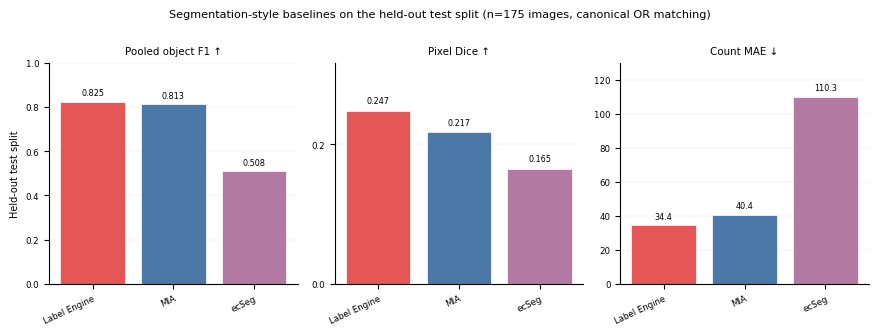

  Saved: fig4_segmentation_test_bars.svg
  Saved: fig4_segmentation_test_bars.png


In [6]:
# ── §5: Test-split comparison of segmentation-style baselines ───────────────
# Sources:
#   release/frozen_results/or_matching/per_image_metrics.csv
#   release/frozen_results/or_matching/summary_by_split.csv
#
# Outputs:
#   fig4_segmentation_test_bars.{svg,png}
#   source_fig4_segmentation_test_bars.csv
#
# F1 convention:
#   Pooled object-level F1 on the held-out test split:
#   F1 = 2 * sum(TP) / [2 * sum(TP) + sum(FP) + sum(FN)].

SEGMENTATION_BASELINES = [
    'Label Engine',
    'MIA',
    'ecSeg',
]

per_image_path = FROZEN_OR / 'per_image_metrics.csv'
summary_by_split_path = FROZEN_OR / 'summary_by_split.csv'

require_file(per_image_path, label='Frozen OR-matching per-image metrics')
require_file(summary_by_split_path, label='Frozen OR-matching split summary')

seg_pim = pd.read_csv(per_image_path)
split_summary = pd.read_csv(summary_by_split_path)

require_columns(
    seg_pim,
    ['model', 'split', 'obj_tp', 'obj_fp', 'obj_fn'],
    label='per_image_metrics.csv',
)

require_columns(
    split_summary,
    ['model', 'split'],
    label='summary_by_split.csv',
)

seg_uid_col = find_metric_column(
    seg_pim,
    candidates=['unique_id', 'uid', 'image_id', 'id'],
    label='image identifier column',
)

seg_pred_count_col = find_metric_column(
    seg_pim,
    candidates=[
        'pred_count',
        'predicted_count',
        'n_pred',
        'pred_objects',
        'pred_object_count',
    ],
    label='predicted count',
)

seg_gt_count_col = find_metric_column(
    seg_pim,
    candidates=[
        'gt_count',
        'ecDNA_gt',
        'gt_objects',
        'gt_object_count',
        'ground_truth_count',
    ],
    label='gold-standard count',
)

seg_pix_dice_col = find_metric_column(
    split_summary,
    candidates=['pix_dice', 'pixel_dice', 'dice', 'mask_dice', 'seg_dice'],
    label='split-level pixel-level Dice',
)

seg_pim = seg_pim.copy()
split_summary = split_summary.copy()

seg_pim['model'] = seg_pim['model'].apply(canonical_model_name)
split_summary['model'] = split_summary['model'].apply(canonical_model_name)

seg_pim['split'] = seg_pim['split'].astype(str).str.lower()
split_summary['split'] = split_summary['split'].astype(str).str.lower()

for col in ['obj_tp', 'obj_fp', 'obj_fn', seg_pred_count_col, seg_gt_count_col]:
    seg_pim[col] = pd.to_numeric(seg_pim[col], errors='coerce')

split_summary[seg_pix_dice_col] = pd.to_numeric(
    split_summary[seg_pix_dice_col],
    errors='coerce',
)

seg_test = seg_pim[
    (seg_pim['split'] == 'test')
    & (seg_pim['model'].isin(SEGMENTATION_BASELINES))
].dropna(
    subset=['obj_tp', 'obj_fp', 'obj_fn', seg_pred_count_col, seg_gt_count_col]
).copy()

if seg_test.empty:
    raise ValueError(
        'No held-out test rows remained for the segmentation-style baselines.'
    )

seg_test['count_error'] = seg_test[seg_pred_count_col] - seg_test[seg_gt_count_col]
seg_test['abs_count_error'] = seg_test['count_error'].abs()

rows = []

for model in SEGMENTATION_BASELINES:
    sub = seg_test[seg_test['model'] == model].copy()

    if sub.empty:
        raise ValueError(f'Missing test-split rows for segmentation baseline: {model}')

    tp = float(sub['obj_tp'].sum())
    fp = float(sub['obj_fp'].sum())
    fn = float(sub['obj_fn'].sum())

    denom = 2 * tp + fp + fn
    object_f1 = (2 * tp / denom) if denom > 0 else np.nan

    rows.append({
        'model': model,
        'n_images': int(sub[seg_uid_col].nunique()),
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'object_f1': object_f1,
        'count_mae': float(sub['abs_count_error'].mean()),
        'count_bias': float(sub['count_error'].mean()),
    })

seg_perf = pd.DataFrame(rows)

test_dice = (
    split_summary[
        (split_summary['split'] == 'test')
        & (split_summary['model'].isin(SEGMENTATION_BASELINES))
    ][['model', seg_pix_dice_col]]
    .rename(columns={seg_pix_dice_col: 'pixel_dice'})
    .drop_duplicates(subset=['model'])
)

seg_perf = seg_perf.merge(
    test_dice,
    on='model',
    how='left',
)

if seg_perf['pixel_dice'].isna().any():
    missing = seg_perf.loc[seg_perf['pixel_dice'].isna(), 'model'].tolist()
    raise ValueError(
        f'Pixel-level Dice missing for segmentation baseline(s): {missing}. '
        'Check summary_by_split.csv.'
    )

seg_perf = (
    seg_perf
    .set_index('model')
    .reindex(SEGMENTATION_BASELINES)
    .reset_index()
)

seg_perf['object_f1_reported_3dp'] = seg_perf['object_f1'].round(3)
seg_perf['pixel_dice_reported_3dp'] = seg_perf['pixel_dice'].round(3)
seg_perf['count_mae_reported_1dp'] = seg_perf['count_mae'].round(1)
seg_perf['count_bias_reported_1dp'] = seg_perf['count_bias'].round(1)

source_csv = OUT_DIR / 'source_fig4_segmentation_test_bars.csv'
seg_perf.to_csv(source_csv, index=False)

print(f'Predicted count column: {seg_pred_count_col}')
print(f'GS count column: {seg_gt_count_col}')
print(f'Pixel-level Dice column: {seg_pix_dice_col}')
print('F1 convention: pooled object-level F1 from TP/FP/FN')
print(f'Saved source data: {source_csv}')

display(
    seg_perf[
        [
            'model',
            'n_images',
            'tp',
            'fp',
            'fn',
            'object_f1',
            'pixel_dice',
            'count_mae',
            'count_bias',
        ]
    ].round(4)
)


# ── Plot: segmentation-style baselines on held-out test split ───────────────
metric_specs = [
    {
        'column': 'object_f1',
        'title': 'Pooled object F1 ↑',
        'ylim': (0, 1.0),
        'formatter': lambda x: f'{x:.3f}',
        'pad': 0.018,
    },
    {
        'column': 'pixel_dice',
        'title': 'Pixel-level Dice ↑',
        'ylim': (0, max(0.30, seg_perf['pixel_dice'].max() * 1.28)),
        'formatter': lambda x: f'{x:.3f}',
        'pad': 0.008,
    },
    {
        'column': 'count_mae',
        'title': 'Count MAE ↓',
        'ylim': (0, seg_perf['count_mae'].max() * 1.18),
        'formatter': lambda x: f'{x:.1f}',
        'pad': seg_perf['count_mae'].max() * 0.025,
    },
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.8, 3.2),
)

x = np.arange(len(seg_perf))
bar_colors = [MODEL_COLORS.get(m, '#777777') for m in seg_perf['model']]

for ax, spec in zip(axes, metric_specs):
    values = seg_perf[spec['column']].to_numpy(dtype=float)

    bars = ax.bar(
        x,
        values,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        seg_perf['model'],
        rotation=25,
        ha='right',
        rotation_mode='anchor',
        fontsize=6.2,
    )

    ax.set_ylim(spec['ylim'])
    ax.set_title(spec['title'], fontsize=7.4)

    for bar, val in zip(bars, values):
        if np.isfinite(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + spec['pad'],
                spec['formatter'](val),
                ha='center',
                va='bottom',
                fontsize=5.8,
            )

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.35,
        alpha=0.35,
    )
    ax.set_axisbelow(True)

    if spec['column'] in ['object_f1', 'pixel_dice']:
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))

axes[0].set_ylabel('Held-out test split')

fig.suptitle(
    (
        'Segmentation-style baselines on the held-out test split '
        '(n=175 images, canonical OR matching)'
    ),
    fontsize=8.1,
    y=1.02,
)

fig.tight_layout()

display(fig)
save_fig(fig, 'fig4_segmentation_test_bars')
plt.close(fig)

### Interpretation

Among the segmentation-style baselines on the held-out test split, Label Engine
performed best, with pooled object-level F1 of 0.825, pixel-level Dice of 0.247, and
count MAE of 34.4 objects. MIA achieved similar but slightly lower pooled
object-level F1 (0.813) and had larger count error (MAE = 40.4). ecSeg performed
substantially worse across all three metrics, with pooled object-level F1 of
0.508 and count MAE of 110.3.

All three segmentation-style baselines showed negative count bias, indicating
systematic undercounting relative to the connected-component GS count. This
supports the main benchmark conclusion that the strongest non-ecCount baseline
is Label Engine, while ecCount remains necessary for the best count-calibrated
object-level performance.count.

## §6 — Anchor classical-pipeline overlay

This section verifies the classical pipeline prediction on the shared anchor
image used throughout the notebook series:

`ncih2170_facs_fish_0723_low_her2_52`

We load the canonical harmonized `Classic (after opt)` prediction mask, extract
8-connected components with the same minimum area threshold used throughout the
benchmark, and overlay the predicted objects on the anchor RGB image.

The left panel shows the full anchor image and the zoom region. The right panel
shows the zoomed region with classical-pipeline predicted components marked by
bounding boxes and centroids.

The component count printed by this cell is the value that should be used in
the Fig. 3 caption. If this value differs from an earlier draft caption, the
caption should be updated to the canonical harmonized-mask count.

Outputs:

- `fig3_anchor_classical_overlay.{svg,png}`
- `source_fig3_anchor_classical_overlay.csv`
- `source_fig3_anchor_classical_overlay_summary.csv`al_overlay_summary.csv`

Classical prediction mask: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/harmonized_masks/classical/ncih2170_facs_fish_0723_low_her2_52.png
Anchor RGB: /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/rgb/ncih2170_facs_fish_0723_low_her2_52.tif
Anchor GT:  /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/gt_image/ncih2170_facs_fish_0723_low_her2_52.tif
Anchor UID: ncih2170_facs_fish_0723_low_her2_52
Image shape: 2,048 × 2,448
Classic after-opt components: 95 (8-connectivity, min area = 3 px)
GT components: 116 (8-connectivity, min area = 3 px)
Locked anchor GT count: 116
Computed GT count matches locked value: True

Fig. 3 caption count to use for the classical overlay: 95 predicted components.
Saved component source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig3_anchor_classical_overlay.csv
Saved summary source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig3_anchor_classical_ov

,unique_id,rgb_path,gt_mask_path,classical_pred_mask_path,image_height_px,image_width_px,min_component_area_px,predicted_components_8conn_minarea,gt_components_8conn_minarea,prediction_foreground_pixels,gt_foreground_pixels,zoom_x0,zoom_y0,zoom_x1,zoom_y1,n_predicted_components_in_zoom
0,ncih2170_facs_fish_0723_low_her2_52,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...,2048,2448,3,95,116,11272,1508,930,1033,1774,1545,32


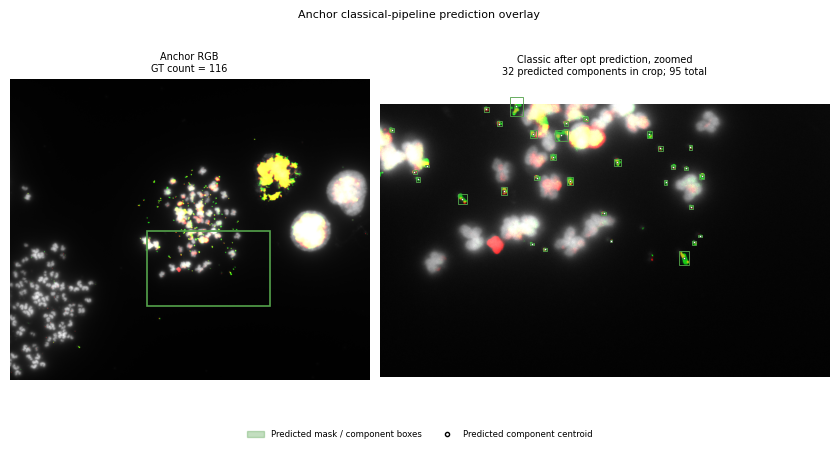

  Saved: fig3_anchor_classical_overlay.svg
  Saved: fig3_anchor_classical_overlay.png


In [7]:
# ── §6: Anchor classical-pipeline overlay ───────────────────────────────────
# Source:
#   release/harmonized_masks/classical/<ANCHOR_UID>.png
#
# Outputs:
#   fig3_anchor_classical_overlay.{svg,png}
#   source_fig3_anchor_classical_overlay.csv
#   source_fig3_anchor_classical_overlay_summary.csv

import cv2

# Local aliases for compatibility with older drafts of Notebook 05.
_REPO = REPO_ROOT if 'REPO_ROOT' in globals() else REPO
_OUT = OUT_DIR if 'OUT_DIR' in globals() else NB05

RGB_DIR = DATA_ROOT / 'rgb'
GT_DIR = DATA_ROOT / 'gt_image'

anchor_bbox = (
    ANCHOR_INSET_BBOX
    if 'ANCHOR_INSET_BBOX' in globals()
    else ANCHOR_INSET
)

MIN_AREA = MIN_COMPONENT_AREA if 'MIN_COMPONENT_AREA' in globals() else 3


def find_first_existing(paths):
    """Return the first existing path from a candidate list."""
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None


def find_image_from_metadata_or_glob(base_dir, uid, row, candidate_cols):
    """Find an image using metadata columns first, then UID glob fallback."""
    base_dir = Path(base_dir)

    for col in candidate_cols:
        if col in row.index and pd.notna(row[col]):
            value = str(row[col])
            p = Path(value)

            if p.is_absolute() and p.exists():
                return p

            p = base_dir / value
            if p.exists():
                return p

    for ext in ['.png', '.tif', '.tiff']:
        candidates = sorted(base_dir.rglob(f'{uid}{ext}'))
        if candidates:
            return candidates[0]

    return None


def extract_components_8conn_minarea(mask, min_area=3):
    """Extract 8-connected components from a binary mask."""
    mask_u8 = (mask > 0).astype(np.uint8)

    n_labels, labels, stats_arr, centroids = cv2.connectedComponentsWithStats(
        mask_u8,
        connectivity=8,
    )

    rows = []
    filtered = np.zeros_like(labels, dtype=np.int32)
    new_id = 1

    for old_id in range(1, n_labels):
        x, y, w, h, area = stats_arr[old_id]

        if int(area) < min_area:
            continue

        cx, cy = centroids[old_id]

        rows.append({
            'component_id': new_id,
            'source_label_id': old_id,
            'x0': int(x),
            'y0': int(y),
            'x1': int(x + w),
            'y1': int(y + h),
            'width_px': int(w),
            'height_px': int(h),
            'area_px': int(area),
            'cx': float(cx),
            'cy': float(cy),
        })

        filtered[labels == old_id] = new_id
        new_id += 1

    components = pd.DataFrame(rows)
    return components, filtered


# ── Locate canonical classical prediction mask ─────────────────────────────
pred_candidates = [
    _REPO / 'release' / 'harmonized_masks' / 'classical' / f'{ANCHOR_UID}.png',
    _REPO / 'release' / 'harmonized_masks' / 'Classic (after opt)' / f'{ANCHOR_UID}.png',
    _REPO / 'outputs' / 'classical_bfr_aft' / 'preds' / 'Classic (after opt)' / f'{ANCHOR_UID}.png',
    _REPO / 'outputs' / 'classical_opt' / 'predictions' / f'{ANCHOR_UID}.png',
    DATA_ROOT.parent / 'predictions' / 'classical_optimised' / f'{ANCHOR_UID}.png',
]

classical_pred_path = find_first_existing(pred_candidates)

if classical_pred_path is None:
    raise FileNotFoundError(
        'Could not find the anchor classical prediction mask. Checked:\n'
        + '\n'.join(f'  - {p}' for p in pred_candidates)
    )

print(f'Classical prediction mask: {classical_pred_path}')


# ── Locate anchor RGB and GS mask ───────────────────────────────────────────
metadata_candidates = [
    DATA_ROOT / 'metadata_internal.csv',
    MANIFESTS / 'metadata.csv',
]

metadata_path = find_first_existing(metadata_candidates)

if metadata_path is None:
    raise FileNotFoundError(
        'Could not find metadata CSV. Checked:\n'
        + '\n'.join(f'  - {p}' for p in metadata_candidates)
    )

metadata = pd.read_csv(metadata_path)

uid_col_meta = find_metric_column(
    metadata,
    candidates=['unique_id', 'uid', 'image_id', 'id'],
    label='metadata image identifier column',
)

anchor_rows = metadata[metadata[uid_col_meta].astype(str) == ANCHOR_UID]

if anchor_rows.empty:
    raise ValueError(
        f'Anchor UID not found in metadata file {metadata_path}: {ANCHOR_UID}'
    )

anchor_row = anchor_rows.iloc[0]

anchor_rgb_path = find_image_from_metadata_or_glob(
    RGB_DIR,
    ANCHOR_UID,
    anchor_row,
    candidate_cols=['rgb_fullpath', 'rgb_path', 'rgb_relpath', 'rgb_filename'],
)

anchor_gt_path = find_image_from_metadata_or_glob(
    GT_DIR,
    ANCHOR_UID,
    anchor_row,
    candidate_cols=['gt_fullpath', 'gt_path', 'gt_relpath', 'gt_image_filename'],
)

if anchor_rgb_path is None:
    raise FileNotFoundError(f'Could not find anchor RGB image for {ANCHOR_UID}')

if anchor_gt_path is None:
    raise FileNotFoundError(f'Could not find anchor GS mask for {ANCHOR_UID}')

print(f'Anchor RGB: {anchor_rgb_path}')
print(f'Anchor GS:  {anchor_gt_path}')


# ── Read images and masks ──────────────────────────────────────────────────
rgb_bgr = cv2.imread(str(anchor_rgb_path), cv2.IMREAD_COLOR)
gt_raw = cv2.imread(str(anchor_gt_path), cv2.IMREAD_GRAYSCALE)
pred_raw = cv2.imread(str(classical_pred_path), cv2.IMREAD_GRAYSCALE)

if rgb_bgr is None:
    raise OSError(f'Could not read anchor RGB image: {anchor_rgb_path}')

if gt_raw is None:
    raise OSError(f'Could not read anchor GS mask: {anchor_gt_path}')

if pred_raw is None:
    raise OSError(f'Could not read classical prediction mask: {classical_pred_path}')

anchor_rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)
gt_bin = (gt_raw > 0).astype(np.uint8)
pred_bin = (pred_raw > 0).astype(np.uint8)

if anchor_rgb.shape[:2] != gt_bin.shape:
    raise ValueError(
        f'RGB and GS mask shape mismatch: '
        f'RGB={anchor_rgb.shape[:2]}, GS={gt_bin.shape}'
    )

if anchor_rgb.shape[:2] != pred_bin.shape:
    raise ValueError(
        f'RGB and prediction mask shape mismatch: '
        f'RGB={anchor_rgb.shape[:2]}, pred={pred_bin.shape}. '
        'The classical mask should be harmonized to original image resolution.'
    )

H, W = anchor_rgb.shape[:2]


# ── Extract connected components ───────────────────────────────────────────
pred_components, pred_labels = extract_components_8conn_minarea(
    pred_bin,
    min_area=MIN_AREA,
)

gt_components, gt_labels = extract_components_8conn_minarea(
    gt_bin,
    min_area=MIN_AREA,
)

n_pred = int(len(pred_components))
n_gt = int(len(gt_components))

print(f'Anchor UID: {ANCHOR_UID}')
print(f'Image shape: {H:,} × {W:,}')
print(f'Classic after-opt components: {n_pred:,} '
      f'(8-connectivity, min area = {MIN_AREA} px)')
print(f'GS components: {n_gt:,} '
      f'(8-connectivity, min area = {MIN_AREA} px)')

if 'ANCHOR_GT_COUNT' in globals():
    print(f'Locked anchor GS count: {ANCHOR_GT_COUNT:,}')
    print(f'Computed GS count matches locked value: {n_gt == ANCHOR_GT_COUNT}')

print(
    '\nFig. 3 caption count to use for the classical overlay: '
    f'{n_pred:,} predicted components.'
)


# ── Add crop-membership annotation and save source data ─────────────────────
x0, y0, x1, y1 = map(int, anchor_bbox)

cx_mid = (x0 + x1) // 2
cy_mid = (y0 + y1) // 2

half_w = max(1, (x1 - x0) * 2)
half_h = max(1, (y1 - y0) * 2)

ex0 = max(0, cx_mid - half_w)
ex1 = min(W, cx_mid + half_w)
ey0 = max(0, cy_mid - half_h)
ey1 = min(H, cy_mid + half_h)

pred_components = pred_components.copy()

pred_components['in_zoom_crop'] = (
    (pred_components['cx'] >= ex0)
    & (pred_components['cx'] < ex1)
    & (pred_components['cy'] >= ey0)
    & (pred_components['cy'] < ey1)
)

component_csv = _OUT / 'source_fig3_anchor_classical_overlay.csv'
pred_components.to_csv(component_csv, index=False)

summary_df = pd.DataFrame([{
    'unique_id': ANCHOR_UID,
    'rgb_path': str(anchor_rgb_path),
    'gt_mask_path': str(anchor_gt_path),
    'classical_pred_mask_path': str(classical_pred_path),
    'image_height_px': H,
    'image_width_px': W,
    'min_component_area_px': MIN_AREA,
    'predicted_components_8conn_minarea': n_pred,
    'gt_components_8conn_minarea': n_gt,
    'prediction_foreground_pixels': int(pred_bin.sum()),
    'gt_foreground_pixels': int(gt_bin.sum()),
    'zoom_x0': ex0,
    'zoom_y0': ey0,
    'zoom_x1': ex1,
    'zoom_y1': ey1,
    'n_predicted_components_in_zoom': int(pred_components['in_zoom_crop'].sum()),
}])

summary_csv = _OUT / 'source_fig3_anchor_classical_overlay_summary.csv'
summary_df.to_csv(summary_csv, index=False)

print(f'Saved component source data: {component_csv}')
print(f'Saved summary source data: {summary_csv}')

display(summary_df)


# ── Plot full anchor and zoomed classical overlay ───────────────────────────
zoom_components = pred_components[pred_components['in_zoom_crop']].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.4, 4.2),
    gridspec_kw={'width_ratios': [1.0, 1.25]},
)

# Full anchor image with zoom box.
axes[0].imshow(anchor_rgb)
axes[0].add_patch(
    mpatches.Rectangle(
        (ex0, ey0),
        ex1 - ex0,
        ey1 - ey0,
        linewidth=1.2,
        edgecolor=MODEL_COLORS.get('Classic (after opt)', '#54A24B'),
        facecolor='none',
    )
)
axes[0].set_title(
    f'Anchor RGB\nGT count = {n_gt}',
    fontsize=7.0,
)
axes[0].axis('off')

# Zoom crop with classical predicted components.
crop_rgb = anchor_rgb[ey0:ey1, ex0:ex1]
crop_pred = pred_bin[ey0:ey1, ex0:ex1]

axes[1].imshow(crop_rgb)
axes[1].imshow(
    np.ma.masked_where(crop_pred == 0, crop_pred),
    cmap='Greens',
    alpha=0.28,
    vmin=0,
    vmax=1,
)

box_color = MODEL_COLORS.get('Classic (after opt)', '#54A24B')

for row in zoom_components.itertuples(index=False):
    local_x0 = row.x0 - ex0
    local_y0 = row.y0 - ey0
    local_w = row.x1 - row.x0
    local_h = row.y1 - row.y0

    axes[1].add_patch(
        mpatches.Rectangle(
            (local_x0, local_y0),
            local_w,
            local_h,
            linewidth=0.65,
            edgecolor=box_color,
            facecolor='none',
            alpha=0.95,
        )
    )

    axes[1].plot(
        row.cx - ex0,
        row.cy - ey0,
        marker='.',
        color='white',
        markersize=3.0,
        markeredgecolor='black',
        markeredgewidth=0.25,
    )

axes[1].set_title(
    (
        'Classic after opt prediction, zoomed\n'
        f'{int(zoom_components.shape[0])} predicted components in crop; '
        f'{n_pred} total'
    ),
    fontsize=7.0,
)
axes[1].axis('off')

legend_handles = [
    mpatches.Patch(
        facecolor=box_color,
        edgecolor=box_color,
        alpha=0.35,
        label='Predicted mask / component boxes',
    ),
    Line2D(
        [0],
        [0],
        marker='.',
        color='white',
        markeredgecolor='black',
        linestyle='None',
        markersize=6,
        label='Predicted component centroid',
    ),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=6.2,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    'Anchor classical-pipeline prediction overlay',
    fontsize=8.0,
    y=1.02,
)

fig.tight_layout(rect=[0, 0.04, 1, 1])

display(fig)
save_fig(fig, 'fig3_anchor_classical_overlay')
plt.close(fig)

## §7 — Qualitative held-out-test gallery

This supplementary gallery shows one representative held-out test image per
benchmark cell line. For each cell line, the selected image is the test-split
image whose `ecDNA_gt` count is closest to that cell line's median test-split
count. This makes the examples reproducible and avoids hand-picking unusually
easy or difficult images.

Each row shows one image. The first panel is the RGB crop. The second panel
shows the gold-standard mask. The remaining panels compare each model prediction
against the same GS reference using a fixed visual encoding:

- **cyan:** GS only
- **orange:** prediction only
- **white:** GS and prediction overlap

Masks are lightly dilated for visual display only, because individual ecDNA
objects are small. All numerical metrics remain computed from the original
binary masks.

Outputs:

- `figS_qualitative_gallery.{svg,png}`
- `source_figS_qualitative_gallery_picks.csv`
- `source_figS_qualitative_gallery_tiles.csv``tive_gallery_tiles.csv`

Representative held-out test images selected:


,cell_line,unique_id,ecDNA_gt,cell_line_test_median_ecDNA_gt,distance_to_cell_line_test_median,selection_rule
0,NCI-H2170,ncih2170_antibiotics_ps_g_56,174,174.0,0.0,held-out test image with ecDNA_gt closest to t...
1,SNU16,snu16_jc_jq1_ic50_24h_67,213,213.0,0.0,held-out test image with ecDNA_gt closest to t...
2,COLO320DM,colo320dm_qpcr_jq1_24h_ctrl_39,41,41.0,0.0,held-out test image with ecDNA_gt closest to t...
3,NCI-H716,ncih716_jc_alo_8nm_24h_13,163,163.0,0.0,held-out test image with ecDNA_gt closest to t...


Saved pick source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_figS_qualitative_gallery_picks.csv


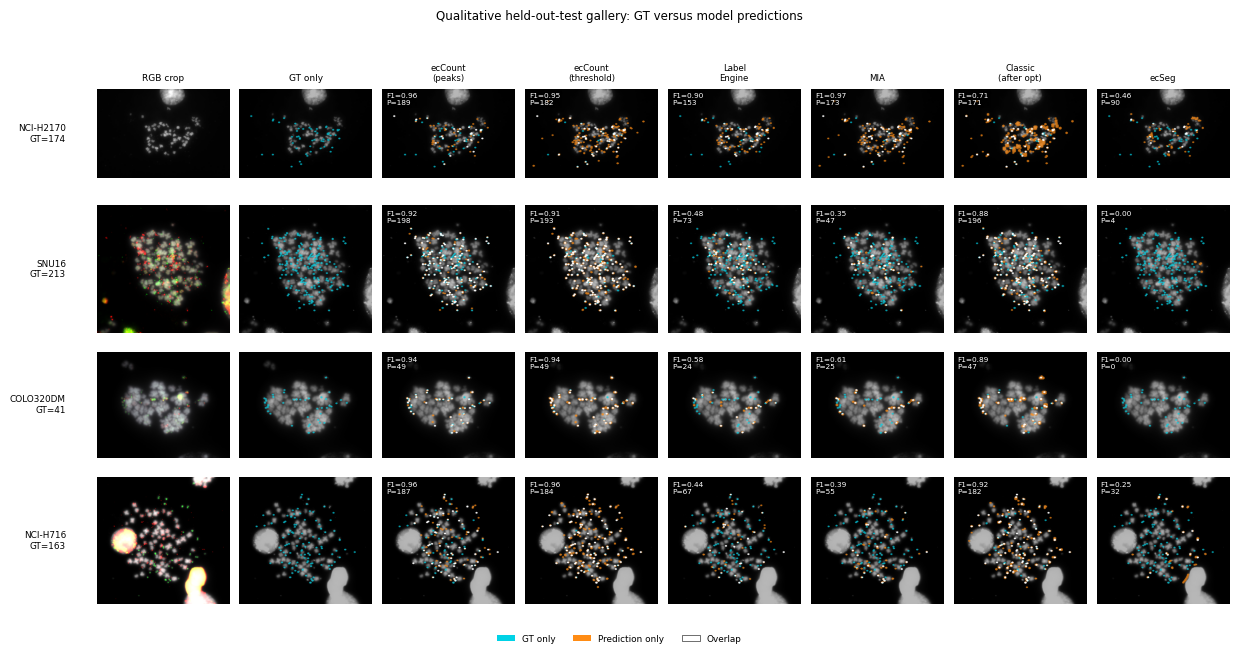

  Saved: figS_qualitative_gallery.svg
  Saved: figS_qualitative_gallery.png
Saved tile source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_figS_qualitative_gallery_tiles.csv
Qualitative GT-vs-pred gallery complete.


In [8]:
# ── §7: Qualitative held-out-test gallery with GS-vs-pred overlays ──────────
# Visual encoding:
#   cyan   = GS only
#   orange = prediction only
#   white  = overlap
#
# Display-only mask dilation is used so punctate ecDNA objects remain visible
# in exported SVG/PNG panels. Metrics are read from the frozen benchmark CSVs.

import cv2
from matplotlib.patches import Patch

_REPO = REPO_ROOT if 'REPO_ROOT' in globals() else REPO
_OUT = OUT_DIR if 'OUT_DIR' in globals() else NB05

if 'save_fig' in globals():
    save_gallery_fig = save_fig
else:
    save_gallery_fig = save_panel


def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def require_file(path, label='file'):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{label} not found: {path}')
    return path


def canonical_cell_line_local(x):
    if 'canonical_cell_line' in globals():
        return canonical_cell_line(x)
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper().replace('-', '').replace('_', '').replace(' ', '')
    return {
        'NCIH2170': 'NCI-H2170',
        'SUM159PT': 'SUM159PT',
        'SNU16': 'SNU16',
        'COLO320DM': 'COLO320DM',
        'NCIH716': 'NCI-H716',
    }.get(s, str(x).strip())


def find_metric_column_local(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )


def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise OSError(f'Could not read RGB image: {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def read_mask(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise OSError(f'Could not read mask: {path}')
    return (img > 0).astype(np.uint8)


def percentile_gray_background(rgb):
    """Convert RGB crop to contrast-normalised grayscale RGB background."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    lo, hi = np.percentile(gray, [1, 99.7])
    if hi <= lo:
        hi = lo + 1.0
    gray = np.clip((gray - lo) / (hi - lo), 0, 1)
    gray = (gray * 255).astype(np.uint8)
    return np.dstack([gray, gray, gray])


def resize_image_for_display(img, max_width=320):
    h, w = img.shape[:2]
    if w <= max_width:
        return img.copy()
    scale = max_width / float(w)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    interp = cv2.INTER_AREA if img.ndim == 3 else cv2.INTER_NEAREST
    return cv2.resize(img, (new_w, new_h), interpolation=interp)


def resize_mask_to_shape(mask, shape_hw):
    h, w = shape_hw
    return cv2.resize(
        mask.astype(np.uint8),
        (w, h),
        interpolation=cv2.INTER_NEAREST,
    ).astype(bool)


def dilate_display_mask(mask_bool, radius=2):
    """Display-only dilation to make tiny puncta visible."""
    if radius <= 0:
        return mask_bool.astype(bool)
    k = 2 * radius + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.dilate(mask_bool.astype(np.uint8), kernel, iterations=1).astype(bool)


def make_gt_pred_overlay(background_rgb, gt_mask, pred_mask=None, display_radius=2):
    """
    Overlay GS and prediction using fixed colors:
      GS only      = cyan
      prediction   = orange
      overlap      = white
    """
    bg = background_rgb.astype(np.float32)
    out = (0.72 * bg).astype(np.float32)

    gt_d = dilate_display_mask(gt_mask, radius=display_radius)

    if pred_mask is None:
        pred_d = np.zeros_like(gt_d, dtype=bool)
    else:
        pred_d = dilate_display_mask(pred_mask, radius=display_radius)

    gt_only = gt_d & ~pred_d
    pred_only = pred_d & ~gt_d
    overlap = gt_d & pred_d

    cyan = np.array([0, 210, 230], dtype=np.float32)
    orange = np.array([255, 140, 20], dtype=np.float32)
    white = np.array([255, 255, 255], dtype=np.float32)

    out[gt_only] = 0.25 * out[gt_only] + 0.75 * cyan
    out[pred_only] = 0.25 * out[pred_only] + 0.75 * orange
    out[overlap] = white

    return np.clip(out, 0, 255).astype(np.uint8)


def gt_centered_crop(mask, margin_px=180, min_side_px=760):
    """Crop around GS foreground with padding."""
    h, w = mask.shape[:2]
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return 0, 0, w, h

    x0, x1 = int(xs.min()), int(xs.max()) + 1
    y0, y1 = int(ys.min()), int(ys.max()) + 1

    cx = (x0 + x1) // 2
    cy = (y0 + y1) // 2

    crop_w = min(max((x1 - x0) + 2 * margin_px, min_side_px), w)
    crop_h = min(max((y1 - y0) + 2 * margin_px, min_side_px), h)

    nx0 = max(0, cx - crop_w // 2)
    ny0 = max(0, cy - crop_h // 2)
    nx1 = min(w, nx0 + crop_w)
    ny1 = min(h, ny0 + crop_h)

    nx0 = max(0, nx1 - crop_w)
    ny0 = max(0, ny1 - crop_h)

    return int(nx0), int(ny0), int(nx1), int(ny1)


def find_image_from_metadata_or_glob(base_dir, uid, row, candidate_cols):
    base_dir = Path(base_dir)

    for col in candidate_cols:
        if col in row.index and pd.notna(row[col]):
            value = str(row[col])
            p = Path(value)

            candidates = []
            if p.is_absolute():
                candidates.append(p)
            else:
                candidates.extend([
                    base_dir / value,
                    DATA_ROOT / value,
                    _REPO / value,
                ])

            found = first_existing(candidates)
            if found is not None:
                return found

    for ext in ['.png', '.tif', '.tiff']:
        candidates = sorted(base_dir.rglob(f'{uid}{ext}'))
        if candidates:
            return candidates[0]

    return None


# ── Select one representative held-out test image per benchmark cell line ───
counts_path = require_file(MANIFESTS / 'counts_master.csv', 'counts_master.csv')
counts = pd.read_csv(counts_path).copy()

uid_col_counts = find_metric_column_local(
    counts,
    ['unique_id', 'uid', 'image_id', 'id'],
    'image identifier column in counts_master',
)
gt_count_col = find_metric_column_local(
    counts,
    ['ecDNA_gt', 'gt_count', 'gt_objects', 'ground_truth_count'],
    'GS count column in counts_master',
)

counts['cell_line'] = counts['cell_line'].apply(canonical_cell_line_local)
counts['split'] = counts['split'].astype(str).str.lower()
counts[gt_count_col] = pd.to_numeric(counts[gt_count_col], errors='coerce')

counts_test = counts[
    (counts['split'] == 'test') &
    counts[gt_count_col].notna()
].copy()

gallery_cell_order = [
    cl for cl in ['NCI-H2170', 'SNU16', 'COLO320DM', 'NCI-H716']
    if cl in set(counts_test['cell_line'])
]

pick_rows = []

for cl in gallery_cell_order:
    sub = counts_test[counts_test['cell_line'] == cl].copy()
    target = float(sub[gt_count_col].median())
    sub['distance_to_cell_line_test_median'] = (sub[gt_count_col] - target).abs()

    picked = (
        sub.sort_values(
            ['distance_to_cell_line_test_median', gt_count_col, uid_col_counts],
            ascending=[True, True, True],
        )
        .iloc[0]
    )

    pick_rows.append({
        'cell_line': cl,
        'unique_id': str(picked[uid_col_counts]),
        'ecDNA_gt': int(picked[gt_count_col]),
        'cell_line_test_median_ecDNA_gt': target,
        'distance_to_cell_line_test_median': float(
            picked['distance_to_cell_line_test_median']
        ),
        'selection_rule': (
            'held-out test image with ecDNA_gt closest to the '
            'cell-line-specific test median'
        ),
    })

picks_df = pd.DataFrame(pick_rows)

if picks_df.empty:
    raise ValueError('No held-out test images were selected for the gallery.')

picks_csv = _OUT / 'source_figS_qualitative_gallery_picks.csv'
picks_df.to_csv(picks_csv, index=False)

print('Representative held-out test images selected:')
display(picks_df)
print(f'Saved pick source data: {picks_csv}')


# ── Load frozen per-image metrics for panel titles ──────────────────────────
pim_path = require_file(FROZEN_OR / 'per_image_metrics.csv', 'per_image_metrics.csv')
pim = pd.read_csv(pim_path).copy()

uid_col_pim = find_metric_column_local(
    pim,
    ['unique_id', 'uid', 'image_id', 'id'],
    'image identifier column in per_image_metrics',
)
f1_col_pim = find_metric_column_local(
    pim,
    ['obj_f1', 'object_f1', 'f1'],
    'object-level F1 column in per_image_metrics',
)
pred_count_col_pim = find_metric_column_local(
    pim,
    ['pred_count', 'predicted_count', 'n_pred', 'prediction_count'],
    'predicted count column in per_image_metrics',
)

pim[uid_col_pim] = pim[uid_col_pim].astype(str)


# ── Metadata and prediction-mask paths ──────────────────────────────────────
metadata_path = first_existing([
    DATA_ROOT / 'metadata_internal.csv',
    MANIFESTS / 'metadata.csv',
])

if metadata_path is None:
    raise FileNotFoundError(
        'Could not find metadata CSV. Checked DATA_ROOT/metadata_internal.csv '
        'and release/manifests/metadata.csv.'
    )

metadata = pd.read_csv(metadata_path)
uid_col_meta = find_metric_column_local(
    metadata,
    ['unique_id', 'uid', 'image_id', 'id'],
    'image identifier column in metadata',
)
metadata[uid_col_meta] = metadata[uid_col_meta].astype(str)

RGB_DIR = DATA_ROOT / 'rgb'
GT_DIR = DATA_ROOT / 'gt_image'

mask_base = _REPO / 'release' / 'harmonized_masks'

model_mask_dirs = {
    'Classic (after opt)': [
        mask_base / 'classical',
        mask_base / 'Classic (after opt)',
    ],
    'Label Engine': [
        mask_base / 'label_engine',
        mask_base / 'Label Engine',
    ],
    'ecSeg': [
        mask_base / 'ecseg',
        mask_base / 'ecSeg',
    ],
    'MIA': [
        mask_base / 'mia',
        mask_base / 'MIA',
    ],
    'ecCount (threshold mask)': [
        mask_base / 'eccount_threshold',
        DATA_ROOT.parent / 'predictions' / 'eccount_threshold',
        (DATA_ROOT.parent / 'predictions' / 'eccount_threshold'),
    ],
    'ecCount (peaks)': [
        mask_base / 'eccount_peaks',
        DATA_ROOT.parent / 'predictions' / 'eccount_peaks',
        (DATA_ROOT.parent / 'predictions' / 'eccount_peaks'),
    ],
}


def find_prediction_mask(model, uid):
    candidates = []

    for d in model_mask_dirs.get(model, []):
        candidates.extend([
            Path(d) / f'{uid}.png',
            Path(d) / f'{uid}.PNG',
        ])

    safe = (
        model.replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
        .replace('/', '_')
    )

    candidates.extend([
        _REPO / 'outputs' / 'predictions' / model / f'{uid}.png',
        _REPO / 'outputs' / 'predictions' / safe / f'{uid}.png',
        DATA_ROOT.parent / 'predictions' / safe / f'{uid}.png',
        _REPO / 'release' / 'predictions' / safe / f'{uid}.png',
    ])

    return first_existing(candidates)


panel_model_labels = {
    'ecCount (peaks)': 'ecCount\n(peaks)',
    'ecCount (threshold mask)': 'ecCount\n(threshold)',
    'Label Engine': 'Label\nEngine',
    'MIA': 'MIA',
    'Classic (after opt)': 'Classic\n(after opt)',
    'ecSeg': 'ecSeg',
}


# ── Draw gallery ────────────────────────────────────────────────────────────
tile_rows = []

n_rows = len(picks_df)
n_cols = 2 + len(MODEL_ORDER_6)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(1.55 * n_cols, 1.55 * n_rows),
    squeeze=False,
)

for r, pick in enumerate(picks_df.itertuples(index=False)):
    uid = pick.unique_id
    cl = pick.cell_line

    md_match = metadata[metadata[uid_col_meta] == uid]
    if md_match.empty:
        raise ValueError(f'UID not found in metadata: {uid}')

    md_row = md_match.iloc[0]

    rgb_path = find_image_from_metadata_or_glob(
        RGB_DIR,
        uid,
        md_row,
        ['rgb_fullpath', 'rgb_path', 'rgb_relpath', 'rgb_filename'],
    )

    gt_path = find_image_from_metadata_or_glob(
        GT_DIR,
        uid,
        md_row,
        ['gt_fullpath', 'gt_path', 'gt_relpath', 'gt_mask_relpath', 'gt_image_filename'],
    )

    if rgb_path is None:
        raise FileNotFoundError(f'RGB image not found for UID: {uid}')
    if gt_path is None:
        raise FileNotFoundError(f'GS mask not found for UID: {uid}')

    rgb = read_rgb(rgb_path)
    gt_mask = read_mask(gt_path)

    if rgb.shape[:2] != gt_mask.shape:
        raise ValueError(
            f'RGB/GT shape mismatch for {uid}: '
            f'RGB={rgb.shape[:2]}, GS={gt_mask.shape}'
        )

    H, W = rgb.shape[:2]
    x0, y0, x1, y1 = gt_centered_crop(gt_mask)

    rgb_crop = rgb[y0:y1, x0:x1]
    gt_crop = gt_mask[y0:y1, x0:x1]

    rgb_disp = resize_image_for_display(rgb_crop, max_width=320)
    bg_disp = percentile_gray_background(rgb_disp)
    gt_disp = resize_mask_to_shape(gt_crop, rgb_disp.shape[:2])

    # RGB crop.
    axes[r, 0].imshow(rgb_disp)
    axes[r, 0].set_title('RGB crop' if r == 0 else '', fontsize=6.5)
    axes[r, 0].set_ylabel(
        f'{cl}\nGT={pick.ecDNA_gt}',
        rotation=0,
        ha='right',
        va='center',
        fontsize=6.4,
        labelpad=22,
    )

    tile_rows.append({
        'row_index': r,
        'cell_line': cl,
        'unique_id': uid,
        'panel': 'RGB crop',
        'model': '',
        'path': str(rgb_path),
        'path_exists': True,
        'crop_x0': x0,
        'crop_y0': y0,
        'crop_x1': x1,
        'crop_y1': y1,
        'object_f1': np.nan,
        'pred_count': np.nan,
        'gt_count': int(pick.ecDNA_gt),
        'foreground_pixels': np.nan,
        'mask_shape_matches_rgb': np.nan,
    })

    # GS-only overlay.
    gt_overlay = make_gt_pred_overlay(
        bg_disp,
        gt_disp,
        pred_mask=None,
        display_radius=2,
    )

    axes[r, 1].imshow(gt_overlay)
    axes[r, 1].set_title('GS only' if r == 0 else '', fontsize=6.5)

    tile_rows.append({
        'row_index': r,
        'cell_line': cl,
        'unique_id': uid,
        'panel': 'GT only',
        'model': 'Ground truth',
        'path': str(gt_path),
        'path_exists': True,
        'crop_x0': x0,
        'crop_y0': y0,
        'crop_x1': x1,
        'crop_y1': y1,
        'object_f1': np.nan,
        'pred_count': np.nan,
        'gt_count': int(pick.ecDNA_gt),
        'foreground_pixels': int(gt_mask.sum()),
        'mask_shape_matches_rgb': True,
    })

    # Model prediction overlays.
    for c, model in enumerate(MODEL_ORDER_6, start=2):
        ax = axes[r, c]
        pred_path = find_prediction_mask(model, uid)

        metric = pim[
            (pim[uid_col_pim] == uid) &
            (pim['model'] == model)
        ]

        if metric.empty:
            obj_f1 = np.nan
            pred_count = np.nan
        else:
            obj_f1 = float(metric[f1_col_pim].iloc[0])
            pred_count = float(metric[pred_count_col_pim].iloc[0])

        if pred_path is None:
            ax.imshow(bg_disp)
            ax.text(
                0.5,
                0.5,
                'missing',
                ha='center',
                va='center',
                fontsize=6.0,
                color='#777777',
                transform=ax.transAxes,
            )

            path_exists = False
            shape_matches = False
            foreground_pixels = np.nan

        else:
            pred_raw = read_mask(pred_path)
            shape_matches = pred_raw.shape == rgb.shape[:2]

            if shape_matches:
                pred_mask = pred_raw
            else:
                # Visualization fallback only; source data records mismatch.
                pred_mask = cv2.resize(
                    pred_raw.astype(np.uint8),
                    (W, H),
                    interpolation=cv2.INTER_NEAREST,
                ).astype(np.uint8)

            pred_crop = pred_mask[y0:y1, x0:x1]
            pred_disp = resize_mask_to_shape(pred_crop, rgb_disp.shape[:2])

            overlay = make_gt_pred_overlay(
                bg_disp,
                gt_disp,
                pred_disp,
                display_radius=2,
            )

            ax.imshow(overlay)
            path_exists = True
            foreground_pixels = int(pred_raw.sum())

        if r == 0:
            ax.set_title(
                panel_model_labels.get(model, model),
                fontsize=6.2,
            )

        if np.isfinite(obj_f1):
            ax.text(
                0.03,
                0.96,
                f'F1={obj_f1:.2f}\nP={pred_count:.0f}',
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=5.3,
                color='white',
                bbox=dict(
                    facecolor='black',
                    alpha=0.45,
                    edgecolor='none',
                    pad=1.5,
                ),
            )

        tile_rows.append({
            'row_index': r,
            'cell_line': cl,
            'unique_id': uid,
            'panel': 'GT-vs-pred overlay',
            'model': model,
            'path': '' if pred_path is None else str(pred_path),
            'path_exists': bool(path_exists),
            'crop_x0': x0,
            'crop_y0': y0,
            'crop_x1': x1,
            'crop_y1': y1,
            'object_f1': obj_f1,
            'pred_count': pred_count,
            'gt_count': int(pick.ecDNA_gt),
            'foreground_pixels': foreground_pixels,
            'mask_shape_matches_rgb': bool(shape_matches),
        })

    for ax in axes[r]:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

legend_handles = [
    Patch(facecolor='#00D2E6', edgecolor='none', label='GS only'),
    Patch(facecolor='#FF8C14', edgecolor='none', label='Prediction only'),
    Patch(facecolor='white', edgecolor='black', linewidth=0.4, label='Overlap'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    frameon=False,
    fontsize=6.4,
    bbox_to_anchor=(0.5, -0.015),
)

fig.suptitle(
    'Qualitative held-out-test gallery: GS versus model predictions',
    fontsize=8.5,
    y=1.02,
)

fig.tight_layout(rect=[0, 0.035, 1, 1])

display(fig)
save_gallery_fig(fig, 'figS_qualitative_gallery')
plt.close(fig)

tiles_df = pd.DataFrame(tile_rows)
tiles_csv = _OUT / 'source_figS_qualitative_gallery_tiles.csv'
tiles_df.to_csv(tiles_csv, index=False)

print(f'Saved tile source data: {tiles_csv}')

missing_tiles = tiles_df[
    (tiles_df['panel'] == 'GT-vs-pred overlay') &
    (~tiles_df['path_exists'].astype(bool))
]

shape_mismatch_tiles = tiles_df[
    (tiles_df['panel'] == 'GT-vs-pred overlay') &
    (tiles_df['path_exists'].astype(bool)) &
    (~tiles_df['mask_shape_matches_rgb'].astype(bool))
]

if len(missing_tiles):
    print('\nWARNING: Missing prediction masks:')
    display(missing_tiles[['cell_line', 'unique_id', 'model']])

if len(shape_mismatch_tiles):
    print('\nWARNING: Prediction masks resized for visualization because shape did not match RGB:')
    display(shape_mismatch_tiles[['cell_line', 'unique_id', 'model', 'path']])

print('Qualitative GS-vs-pred gallery complete.')

## §8 — Count-agreement scatter for the three best count models

This panel focuses on count agreement rather than object-level detection F1.
For each image, we compare the predicted ecDNA count with the gold-standard
connected-component count. The three models with the lowest count MAE are shown.

Each panel plots one point per benchmark image. The dashed diagonal is the
ideal `predicted count = GT count` line. Points above the diagonal indicate
over-counting, and points below the diagonal indicate under-counting. The panel
titles report count MAE, signed count bias, and Pearson correlation.

Because the benchmark contains both low-count and high-count images, the axes
use a symmetric-log scale. This preserves zero-count images while keeping dense
high-count regions readable.

Outputs:

- `fig6_count_agreement_top3.{svg,png}`
- `source_fig6_count_agreement_top3.csv`
- `source_fig6_count_agreement_top3_summary.csv`t_top3_summary.csv`

Loaded count-agreement source: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook03/source_fig6_count_agreement.csv
Rows: 6,870
Columns: ['model', 'split', 'cell_line_display', 'density_bin', 'gt_count', 'pred_count', 'abs_error', 'signed_error', 'gt_count_plot', 'pred_count_plot']

Count-agreement summary, sorted by MAE:


,model,n_images,count_mae,count_bias,count_pearson_r,gt_count_median,pred_count_median,gt_count_max,pred_count_max
0,ecCount (peaks),1145,13.1118,0.3555,0.9908,159.0,157.0,1687.0,1724.0
1,ecCount (threshold mask),1145,18.0769,-11.4410,0.9870,159.0,151.0,1687.0,1422.0
2,Label Engine,1145,36.0279,-28.7633,0.9188,159.0,129.0,1687.0,1641.0
3,Classic (after opt),1145,44.9240,-24.2847,0.9134,159.0,140.0,1687.0,1108.0
4,MIA,1145,46.9520,-40.6201,0.8819,159.0,116.0,1687.0,1364.0
5,ecSeg,1145,121.4865,-118.4681,0.6041,159.0,43.0,1687.0,830.0



Models shown in Fig. 6 count-agreement panel:
  1. ecCount (peaks): MAE=13.1, bias=+0.4, r=0.991
  2. ecCount (threshold mask): MAE=18.1, bias=-11.4, r=0.987
  3. Label Engine: MAE=36.0, bias=-28.8, r=0.919

Saved long-form source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig6_count_agreement_top3.csv
Saved summary source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/source_fig6_count_agreement_top3_summary.csv


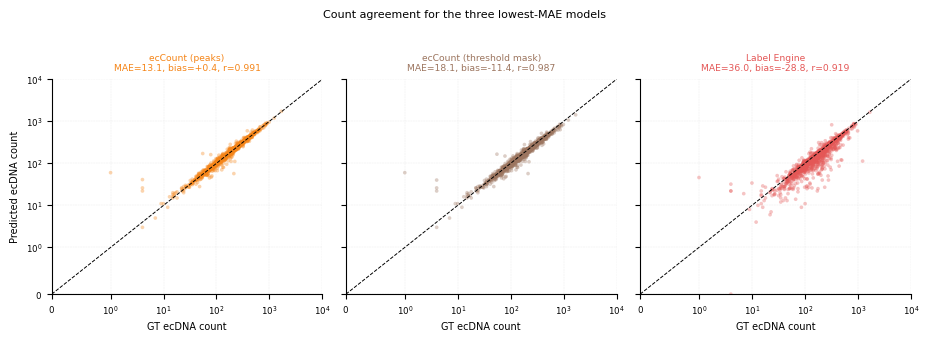

  Saved: fig6_count_agreement_top3.svg
  Saved: fig6_count_agreement_top3.png


In [9]:
# ── §8: Count-agreement scatter for the three best count models ─────────────
# Goal:
#   Compare predicted count versus GS count for the three models with the
#   lowest count MAE across the full 1,145-image benchmark.

def _find_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )


def _safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(x) < 2 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


# Resolve paths in a way that works whether this notebook uses REPO/NB05
# or REPO_ROOT/OUT_DIR naming.
_REPO = REPO if 'REPO' in globals() else REPO_ROOT
_OUT = NB05 if 'NB05' in globals() else OUT_DIR

agree_path = first_existing([
    NB03 / 'source_fig6_count_agreement.csv',
    _REPO / 'source_fig6_count_agreement.csv',
    FROZEN_OR / 'per_image_metrics.csv',
])

if agree_path is None:
    raise FileNotFoundError(
        'Could not find count-agreement source data. Checked '
        'notebook03/source_fig6_count_agreement.csv and '
        'release/frozen_results/or_matching/per_image_metrics.csv.'
    )

agree = pd.read_csv(agree_path).copy()
print(f'Loaded count-agreement source: {agree_path}')
print(f'Rows: {len(agree):,}')
print(f'Columns: {list(agree.columns)}')

model_col = _find_col(agree, ['model'], 'model column')
gt_col = _find_col(
    agree,
    ['gt_count', 'ecDNA_gt', 'ground_truth_count'],
    'GS count column',
)
pred_col = _find_col(
    agree,
    ['pred_count', 'predicted_count', 'prediction_count'],
    'predicted count column',
)

uid_col = None
for candidate in ['unique_id', 'uid', 'image_id', 'id']:
    if candidate in agree.columns:
        uid_col = candidate
        break

if uid_col is None:
    agree['unique_id'] = np.arange(len(agree))
    uid_col = 'unique_id'

# Keep only the six benchmark models for the main comparison.
model_order_6 = MODEL_ORDER_6 if 'MODEL_ORDER_6' in globals() else MODEL_ORDER

agree = agree[agree[model_col].isin(model_order_6)].copy()
agree[gt_col] = pd.to_numeric(agree[gt_col], errors='coerce')
agree[pred_col] = pd.to_numeric(agree[pred_col], errors='coerce')
agree = agree.dropna(subset=[gt_col, pred_col])

# Compute count summary directly from the plotted data.
summary_rows = []
for model, sub in agree.groupby(model_col, sort=False):
    gt = sub[gt_col].to_numpy(dtype=float)
    pred = sub[pred_col].to_numpy(dtype=float)
    err = pred - gt

    summary_rows.append({
        'model': model,
        'n_images': int(len(sub)),
        'count_mae': float(np.mean(np.abs(err))),
        'count_bias': float(np.mean(err)),
        'count_pearson_r': _safe_pearson(gt, pred),
        'gt_count_median': float(np.median(gt)),
        'pred_count_median': float(np.median(pred)),
        'gt_count_max': float(np.max(gt)),
        'pred_count_max': float(np.max(pred)),
    })

count_summary = (
    pd.DataFrame(summary_rows)
    .sort_values('count_mae', ascending=True)
    .reset_index(drop=True)
)

top3_models = count_summary.head(3)['model'].tolist()

print('\nCount-agreement summary, sorted by MAE:')
display(count_summary.round(4))

print('\nModels shown in Fig. 6 count-agreement panel:')
for i, model in enumerate(top3_models, start=1):
    row = count_summary[count_summary['model'] == model].iloc[0]
    print(
        f'  {i}. {model}: '
        f'MAE={row["count_mae"]:.1f}, '
        f'bias={row["count_bias"]:+.1f}, '
        f'r={row["count_pearson_r"]:.3f}'
    )

# Save source data.
top3_long = agree[agree[model_col].isin(top3_models)].copy()
top3_long = top3_long.rename(columns={
    model_col: 'model',
    uid_col: 'unique_id',
    gt_col: 'gt_count',
    pred_col: 'pred_count',
})

top3_summary = count_summary[count_summary['model'].isin(top3_models)].copy()

long_csv = _OUT / 'source_fig6_count_agreement_top3.csv'
summary_csv = _OUT / 'source_fig6_count_agreement_top3_summary.csv'

top3_long.to_csv(long_csv, index=False)
top3_summary.to_csv(summary_csv, index=False)

print(f'\nSaved long-form source data: {long_csv}')
print(f'Saved summary source data: {summary_csv}')


# ── Plot: predicted count versus GS count ───────────────────────────────────
model_colors = MODEL_COLOURS if 'MODEL_COLOURS' in globals() else MODEL_COLORS

plot_df = top3_long.copy()

global_max = float(
    np.nanmax([
        plot_df['gt_count'].max(),
        plot_df['pred_count'].max(),
        1.0,
    ])
)
axis_hi = 10 ** np.ceil(np.log10(global_max))
axis_hi = max(axis_hi, 10)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(9.3, 3.2),
    sharex=True,
    sharey=True,
)

for ax, model in zip(axes, top3_models):
    sub = plot_df[plot_df['model'] == model].copy()
    summary_row = top3_summary[top3_summary['model'] == model].iloc[0]

    ax.scatter(
        sub['gt_count'],
        sub['pred_count'],
        s=7,
        alpha=0.35,
        color=model_colors.get(model, '#777777'),
        edgecolor='none',
        rasterized=True,
    )

    ax.plot(
        [0, axis_hi],
        [0, axis_hi],
        color='black',
        linestyle='--',
        linewidth=0.7,
        label='ideal',
    )

    ax.set_xscale('symlog', linthresh=1)
    ax.set_yscale('symlog', linthresh=1)
    ax.set_xlim(0, axis_hi)
    ax.set_ylim(0, axis_hi)

    ax.set_title(
        f'{model}\n'
        f'MAE={summary_row["count_mae"]:.1f}, '
        f'bias={summary_row["count_bias"]:+.1f}, '
        f'r={summary_row["count_pearson_r"]:.3f}',
        fontsize=6.6,
        color=model_colors.get(model, 'black'),
    )

    ax.set_xlabel('GS ecDNA count')
    ax.grid(
        which='both',
        linestyle='--',
        linewidth=0.35,
        alpha=0.25,
    )
    ax.set_axisbelow(True)

axes[0].set_ylabel('Predicted ecDNA count')

fig.suptitle(
    'Count agreement for the three lowest-MAE models',
    fontsize=8,
    y=1.04,
)

fig.tight_layout()

display(fig)

if 'save_fig' in globals():
    save_fig(fig, 'fig6_count_agreement_top3')
else:
    save_panel(fig, 'fig6_count_agreement_top3')

plt.close(fig)

The three displayed models were selected automatically by lowest count MAE.
ecCount peaks achieved the best count agreement, with the lowest MAE
(13.1 ecDNA objects/image), near-zero signed bias (+0.4), and the highest
Pearson correlation with GS count (r = 0.991). The threshold-mask version
also tracked GS count closely but showed a modest negative bias, consistent
with nearby foci being merged into connected components. Label Engine was the
strongest external baseline for count agreement but showed substantially larger
MAE and systematic under-counting.

Thus, the peak-based ecCount output is not only the strongest object-level
detector, but also the best-calibrated model for image-level ecDNA count
estimation.

## §9 — Locked pixel-Dice numbers

This section locks the pixel-level Dice values used for manuscript reporting.
Pixel-level Dice is read directly from the frozen OR-matching benchmark summaries and
is not recomputed in this notebook.

The all-image values correspond to the 1,145-image benchmark set. When
`summary_by_split.csv` is available, we also report the held-out test-split
values for comparison. The accompanying plot is a visual check that the
test-split Dice values are consistent with the full-benchmark Dice values.

Outputs:
- `pixel_dice_locked_numbers.csv`
- `figS_pixel_dice_locked_numbers.svg`
- `figS_pixel_dice_locked_numbers.png`

,subset,model,pixel_dice_raw,n_images,pixel_dice_reported_3dp
0,all_images,ecCount (peaks),0.320538,1145,0.321
1,all_images,ecCount (threshold mask),0.310865,1145,0.311
2,all_images,Label Engine,0.247474,1145,0.247
3,all_images,MIA,0.206260,1145,0.206
4,all_images,Classic (after opt),0.126072,1145,0.126
5,all_images,ecSeg,0.146012,1145,0.146
6,test_only,ecCount (peaks),0.309994,175,0.310
7,test_only,ecCount (threshold mask),0.301824,175,0.302
8,test_only,Label Engine,0.247414,175,0.247
9,test_only,MIA,0.217194,175,0.217


Saved locked pixel-Dice numbers: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05/pixel_dice_locked_numbers.csv

Caption-ready all-image pixel Dice values:
  ecCount (peaks): 0.321
  ecCount (threshold mask): 0.311
  Label Engine: 0.247
  MIA: 0.206
  Classic (after opt): 0.126
  ecSeg: 0.146


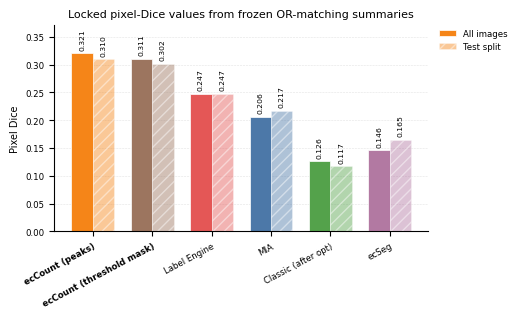

Saved: figS_pixel_dice_locked_numbers.svg
Saved: figS_pixel_dice_locked_numbers.png


In [10]:
# ── §9: Lock and plot pixel-Dice numbers for manuscript reporting ───────────
# Sources:
#   release/frozen_results/or_matching/summary_overall.csv
#   release/frozen_results/or_matching/summary_by_split.csv
#
# Outputs:
#   pixel_dice_locked_numbers.csv
#   figS_pixel_dice_locked_numbers.{svg,png}

SUMMARY_OVERALL_CSV = FROZEN_OR / 'summary_overall.csv'
SUMMARY_BY_SPLIT_CSV = FROZEN_OR / 'summary_by_split.csv'

if not SUMMARY_OVERALL_CSV.exists():
    raise FileNotFoundError(f'Frozen overall summary not found: {SUMMARY_OVERALL_CSV}')

summary_overall_locked = pd.read_csv(SUMMARY_OVERALL_CSV)

required_cols = {'model', 'pix_dice'}
missing = required_cols - set(summary_overall_locked.columns)
if missing:
    raise KeyError(
        f'{SUMMARY_OVERALL_CSV.name} is missing required columns: {sorted(missing)}. '
        f'Available columns: {list(summary_overall_locked.columns)}'
    )


def _find_n_images_col(df):
    """Return an image-count column if one exists."""
    for col in ['n_images', 'num_images', 'n', 'count']:
        if col in df.columns:
            return col
    return None


def _extract_pixel_dice_rows(df, subset_label):
    """Extract ordered pixel-Dice rows for the six benchmark models."""
    n_col = _find_n_images_col(df)

    keep_cols = ['model', 'pix_dice']
    if n_col is not None:
        keep_cols.append(n_col)

    out = (
        df[df['model'].isin(MODEL_ORDER_6)][keep_cols]
        .set_index('model')
        .reindex(MODEL_ORDER_6)
        .reset_index()
    )

    out.insert(0, 'subset', subset_label)

    if n_col is not None:
        out = out.rename(columns={n_col: 'n_images'})
    else:
        out.insert(2, 'n_images', np.nan)

    out = out.rename(columns={'pix_dice': 'pixel_dice_raw'})
    return out


# All benchmark images.
pixel_dice_rows = [
    _extract_pixel_dice_rows(summary_overall_locked, subset_label='all_images')
]

# Held-out test split, when available.
if SUMMARY_BY_SPLIT_CSV.exists():
    summary_by_split_locked = pd.read_csv(SUMMARY_BY_SPLIT_CSV)

    required_split_cols = {'model', 'split', 'pix_dice'}
    missing_split = required_split_cols - set(summary_by_split_locked.columns)

    if missing_split:
        print(
            f'Warning: {SUMMARY_BY_SPLIT_CSV.name} exists but is missing '
            f'{sorted(missing_split)}. Test-split pixel-level Dice will be skipped.'
        )
    else:
        test_summary = summary_by_split_locked[
            summary_by_split_locked['split'].astype(str).str.lower() == 'test'
        ].copy()

        if len(test_summary) == 0:
            print(f'Warning: no split == "test" rows found in {SUMMARY_BY_SPLIT_CSV.name}.')
        else:
            pixel_dice_rows.append(
                _extract_pixel_dice_rows(test_summary, subset_label='test_only')
            )
else:
    print(f'Optional split summary not found; exporting all-image values only: {SUMMARY_BY_SPLIT_CSV}')


pixel_dice_locked = pd.concat(pixel_dice_rows, ignore_index=True)

pixel_dice_locked['pixel_dice_reported_3dp'] = pixel_dice_locked['pixel_dice_raw'].map(
    lambda x: f'{x:.3f}' if pd.notna(x) else ''
)

subset_order = ['all_images', 'test_only']
pixel_dice_locked['subset'] = pd.Categorical(
    pixel_dice_locked['subset'],
    categories=subset_order,
    ordered=True,
)
pixel_dice_locked['model'] = pd.Categorical(
    pixel_dice_locked['model'],
    categories=MODEL_ORDER_6,
    ordered=True,
)

pixel_dice_locked = (
    pixel_dice_locked
    .sort_values(['subset', 'model'])
    .reset_index(drop=True)
)

out_csv = NB05 / 'pixel_dice_locked_numbers.csv'
pixel_dice_locked.to_csv(out_csv, index=False)

display(pixel_dice_locked)
print(f'Saved locked pixel-Dice numbers: {out_csv}')

print('\nCaption-ready all-image pixel-level Dice values:')
for row in pixel_dice_locked[pixel_dice_locked['subset'] == 'all_images'].itertuples(index=False):
    print(f'  {row.model}: {row.pixel_dice_reported_3dp}')


# ── Visual QC plot: all images versus held-out test split ───────────────────
plot_df = pixel_dice_locked.copy()

model_color_map = globals().get('MODEL_COLORS', globals().get('MODEL_COLOURS', {}))

fig, ax = plt.subplots(figsize=(6.4, 3.2))

x = np.arange(len(MODEL_ORDER_6))
bar_w = 0.36

all_df = (
    plot_df[plot_df['subset'] == 'all_images']
    .set_index('model')
    .reindex(MODEL_ORDER_6)
)

test_df = (
    plot_df[plot_df['subset'] == 'test_only']
    .set_index('model')
    .reindex(MODEL_ORDER_6)
)

all_vals = all_df['pixel_dice_raw'].astype(float).values
test_vals = test_df['pixel_dice_raw'].astype(float).values if len(test_df) else np.full(len(MODEL_ORDER_6), np.nan)

colors = [model_color_map.get(m, '#808080') for m in MODEL_ORDER_6]

bars_all = ax.bar(
    x - bar_w / 2,
    all_vals,
    width=bar_w,
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    label='All images',
)

bars_test = ax.bar(
    x + bar_w / 2,
    test_vals,
    width=bar_w,
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.45,
    hatch='///',
    label='Test split',
)

for bars, vals in [(bars_all, all_vals), (bars_test, test_vals)]:
    for bar, val in zip(bars, vals):
        if np.isfinite(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.006,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=5.5,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(
    MODEL_ORDER_6,
    rotation=28,
    ha='right',
    rotation_mode='anchor',
)

ax.set_ylabel('Pixel-level Dice')
ax.set_title('Locked pixel-Dice values from frozen OR-matching summaries')
ax.set_ylim(0, max(0.36, np.nanmax([np.nanmax(all_vals), np.nanmax(test_vals)]) + 0.05))

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=6.2,
)

fig.tight_layout(rect=[0, 0, 0.82, 1])

display(fig)

svg_path = NB05 / 'figS_pixel_dice_locked_numbers.svg'
png_path = NB05 / 'figS_pixel_dice_locked_numbers.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=150, bbox_inches='tight')
plt.close(fig)

print(f'Saved: {svg_path.name}')
print(f'Saved: {png_path.name}')

The locked pixel-Dice values confirm that ecCount also has the strongest
pixel-level agreement with the GS masks. On the full 1,145-image benchmark,
ecCount peaks achieved the highest Dice score (0.321), followed by the
ecCount threshold mask (0.311) and Label Engine (0.247). The same pattern was
observed on the held-out test split, where ecCount peaks and threshold mask
again had the highest Dice scores (0.310 and 0.302, respectively).

Pixel-level Dice is reported as a complementary segmentation metric rather than the
primary endpoint. Because ecDNA FISH foci are small punctate objects, small
localization or mask-boundary differences can substantially reduce pixel-level
overlap even when object detection and counting are correct. Therefore, the
main benchmark conclusions are based on object-level F1 and count agreement,
with pixel-level Dice used as an additional mask-overlap check.

## Section 10 — Output manifest

Finally, we write a manifest of every figure and source-data file generated by
Notebook 05. The manifest is saved as `notebook05_output_manifest.csv` in
`release/figures/notebook05/`.

The table below is intended as a reproducibility checklist: each generated
panel has a corresponding SVG/PNG preview, and each quantitative panel has an
associated CSV source-data file.

In [11]:
# ── Section 10: Output manifest ─────────────────────────────────────────────
def classify_output_file(path):
    """Assign a simple paper-artifact file type from extension and filename."""
    if path.suffix.lower() in {'.svg', '.png'}:
        return 'figure'
    if path.suffix.lower() == '.csv':
        if path.name == 'notebook05_output_manifest.csv':
            return 'manifest'
        if path.name.startswith('source_') or path.name.endswith('_numbers.csv'):
            return 'source_data'
        return 'csv'
    return 'other'


def build_output_manifest(out_dir, repo_root):
    """Build a file manifest for all files written by this notebook."""
    rows = []

    for path in sorted(Path(out_dir).iterdir()):
        if not path.is_file():
            continue
        if path.name.startswith('.'):
            continue

        size_kb = path.stat().st_size / 1024

        try:
            rel_path = path.relative_to(repo_root)
        except ValueError:
            rel_path = path

        rows.append({
            'filename': path.name,
            'file_type': classify_output_file(path),
            'size_kb': round(size_kb, 1),
            'path': str(rel_path),
        })

    return pd.DataFrame(rows)


# Write once so the manifest file itself exists, then rebuild and overwrite.
manifest_path = NB05 / 'notebook05_output_manifest.csv'

manifest = build_output_manifest(NB05, REPO)
manifest.to_csv(manifest_path, index=False)

manifest = build_output_manifest(NB05, REPO)
manifest.to_csv(manifest_path, index=False)

display(manifest)

print(f'Files saved to: {NB05}')
print(f'Total files: {len(manifest)}')
print(f'Output manifest saved: {manifest_path.name}')

print('\nFiles:')
for row in manifest.itertuples(index=False):
    print(
        f'  {row.filename:65s} '
        f'{row.file_type:12s} '
        f'{row.size_kb:8.1f} KB'
    )

,filename,file_type,size_kb,path
0,fig3_anchor_classical_overlay.png,figure,342.2,release/figures/notebook05/fig3_anchor_classic...
1,fig3_anchor_classical_overlay.svg,figure,1417.6,release/figures/notebook05/fig3_anchor_classic...
2,fig3_classical_wilcoxon_delta.png,figure,54.4,release/figures/notebook05/fig3_classical_wilc...
3,fig3_classical_wilcoxon_delta.svg,figure,49.3,release/figures/notebook05/fig3_classical_wilc...
4,fig4_segmentation_test_bars.png,figure,45.0,release/figures/notebook05/fig4_segmentation_t...
5,fig4_segmentation_test_bars.svg,figure,22.4,release/figures/notebook05/fig4_segmentation_t...
6,fig6_count_agreement_top3.png,figure,96.6,release/figures/notebook05/fig6_count_agreemen...
7,fig6_count_agreement_top3.svg,figure,123.1,release/figures/notebook05/fig6_count_agreemen...
8,fig6_f1_by_cell_line_heatmap.png,figure,53.3,release/figures/notebook05/fig6_f1_by_cell_lin...
9,fig6_f1_by_cell_line_heatmap.svg,figure,27.8,release/figures/notebook05/fig6_f1_by_cell_lin...


Files saved to: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook05
Total files: 38
Output manifest saved: notebook05_output_manifest.csv

Files:
  fig3_anchor_classical_overlay.png                                 figure          342.2 KB
  fig3_anchor_classical_overlay.svg                                 figure         1417.6 KB
  fig3_classical_wilcoxon_delta.png                                 figure           54.4 KB
  fig3_classical_wilcoxon_delta.svg                                 figure           49.3 KB
  fig4_segmentation_test_bars.png                                   figure           45.0 KB
  fig4_segmentation_test_bars.svg                                   figure           22.4 KB
  fig6_count_agreement_top3.png                                     figure           96.6 KB
  fig6_count_agreement_top3.svg                                     figure          123.1 KB
  fig6_f1_by_cell_line_heatmap.png                                  figure           53

---

**Notebook 05 complete.**

Deliverables in `release/figures/notebook05/` include:

- Wilcoxon paired-test source data and delta-distribution plot for classical before/after optimisation.
- GS count-disclosure scatter plot comparing coordinate counts with connected-component GS counts.
- Per-cell-line F1 heatmaps for the six-model benchmark and seven-condition test-only comparison.
- Global performance summaries for object F1, pixel-level Dice, and count MAE.
- Test-split segmentation-baseline comparison.
- Anchor classical-pipeline overlay, if the required prediction mask was available.
- Qualitative held-out-test gallery, if all required masks were available.
- Top-three count-agreement scatter plot.
- Locked pixel-Dice table for caption and documentation use.
- `notebook05_output_manifest.csv`, listing all generated files.

This completes the notebook series. The next step is to copy the locked numbers
and finalized figure outputs into the manuscript, supplementary methods, figure
captions, and release documentation.